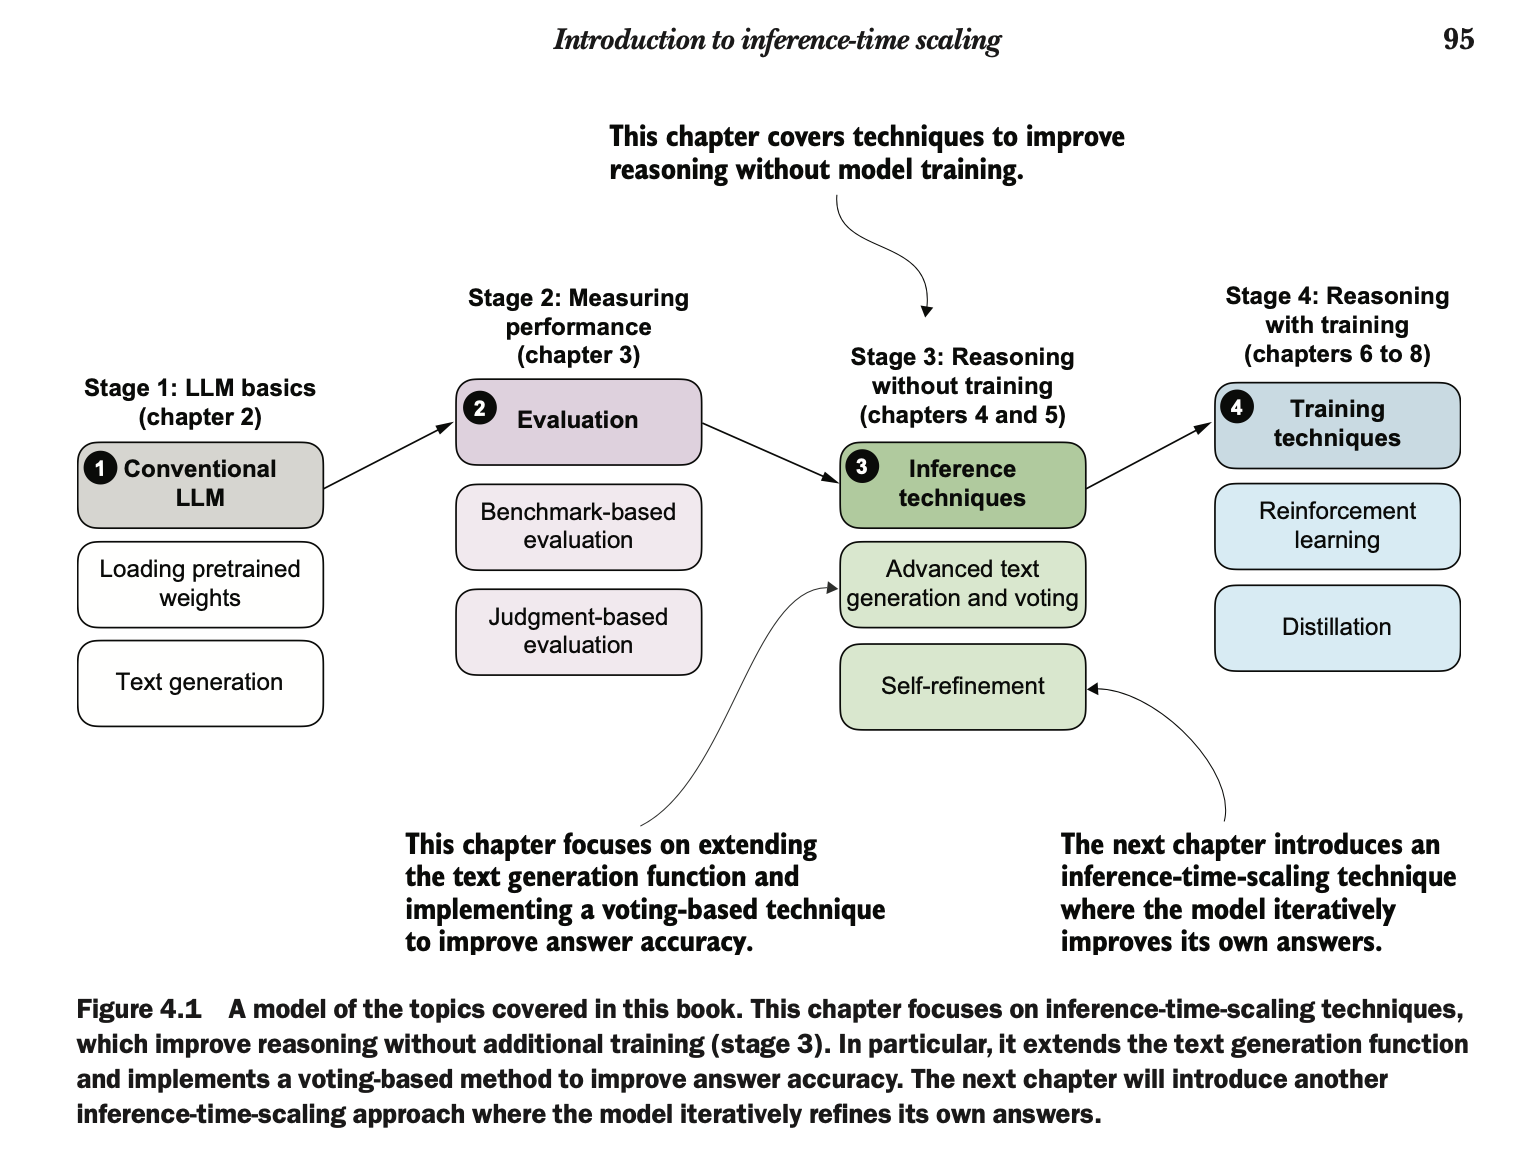


# 4.1 Introduction to inference-time scaling

- There are two main strategies to improve reasoning:
  - Increasing training compute
  - Increasing inference compute (also known as inference-time scaling or test-time
    scaling)

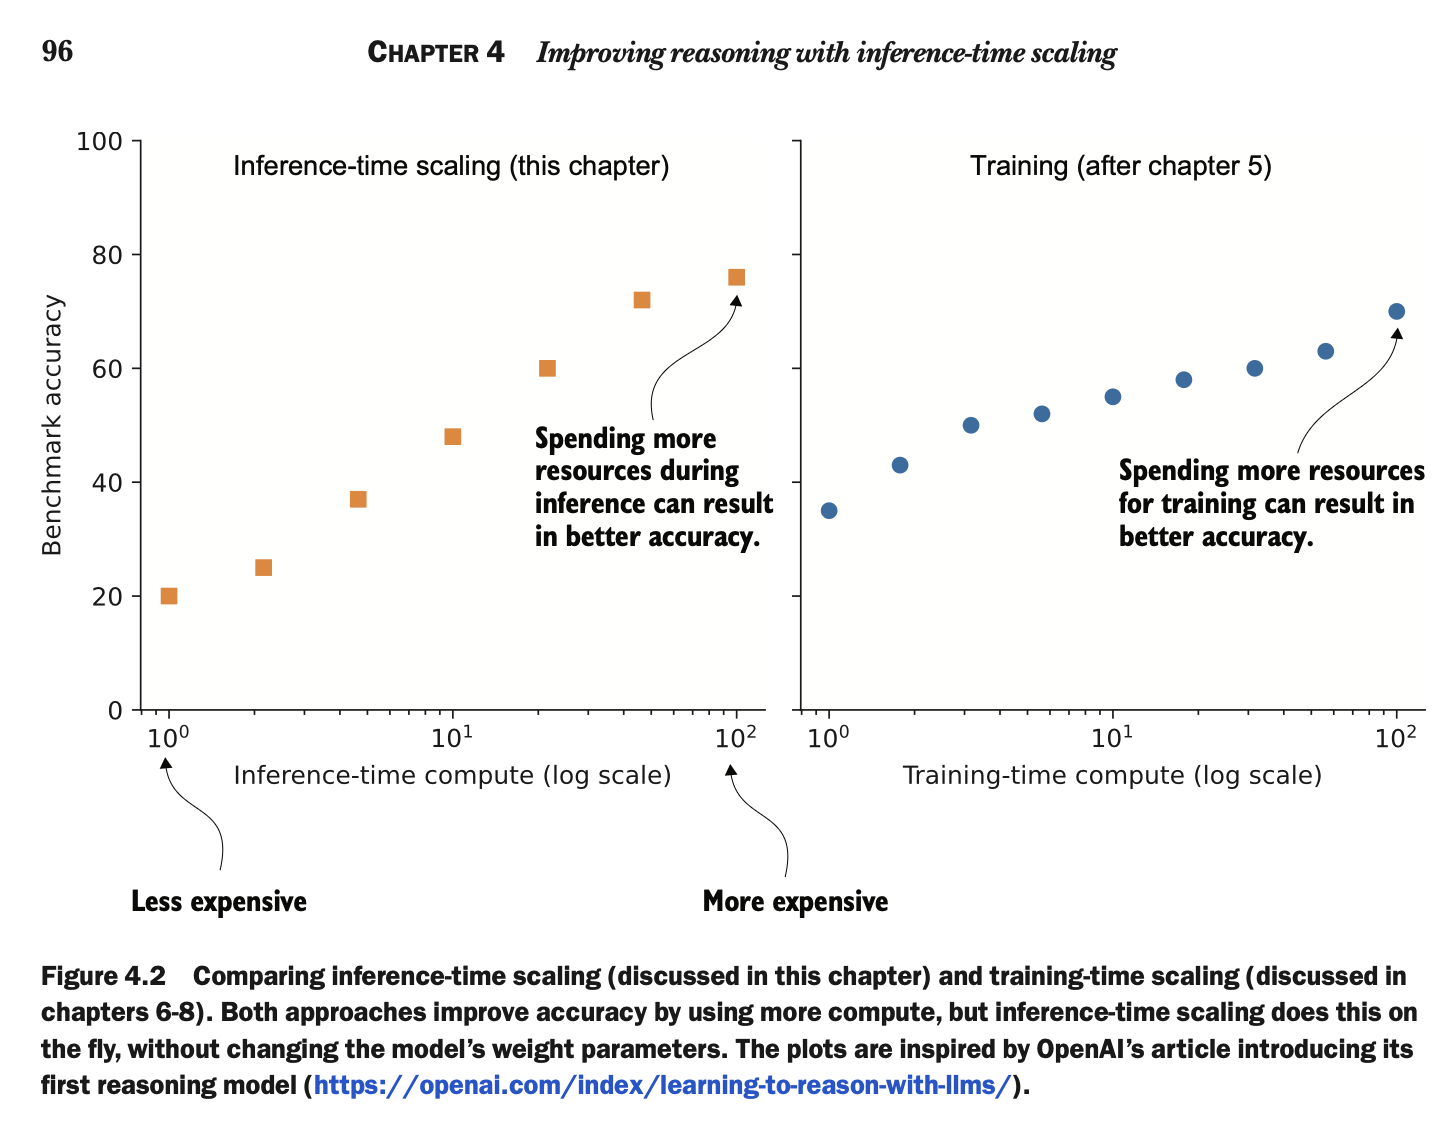


- In this book, we’ll focus on three practical and foundational inference-time techniques (illustrated in figure 4.3):
  - Method 1: Extending the chain-of-thought response to prompt the model
    to explain its reasoning. This simple technique can substantially improve
    accuracy.
  - Method 2: Parallel sampling via self-consistency, where the model generates multiple responses and selects the most frequent one.
  - Method 3: Iterative self-refinement, where the model reviews and improves its own
    reasoning and answers across multiple steps.


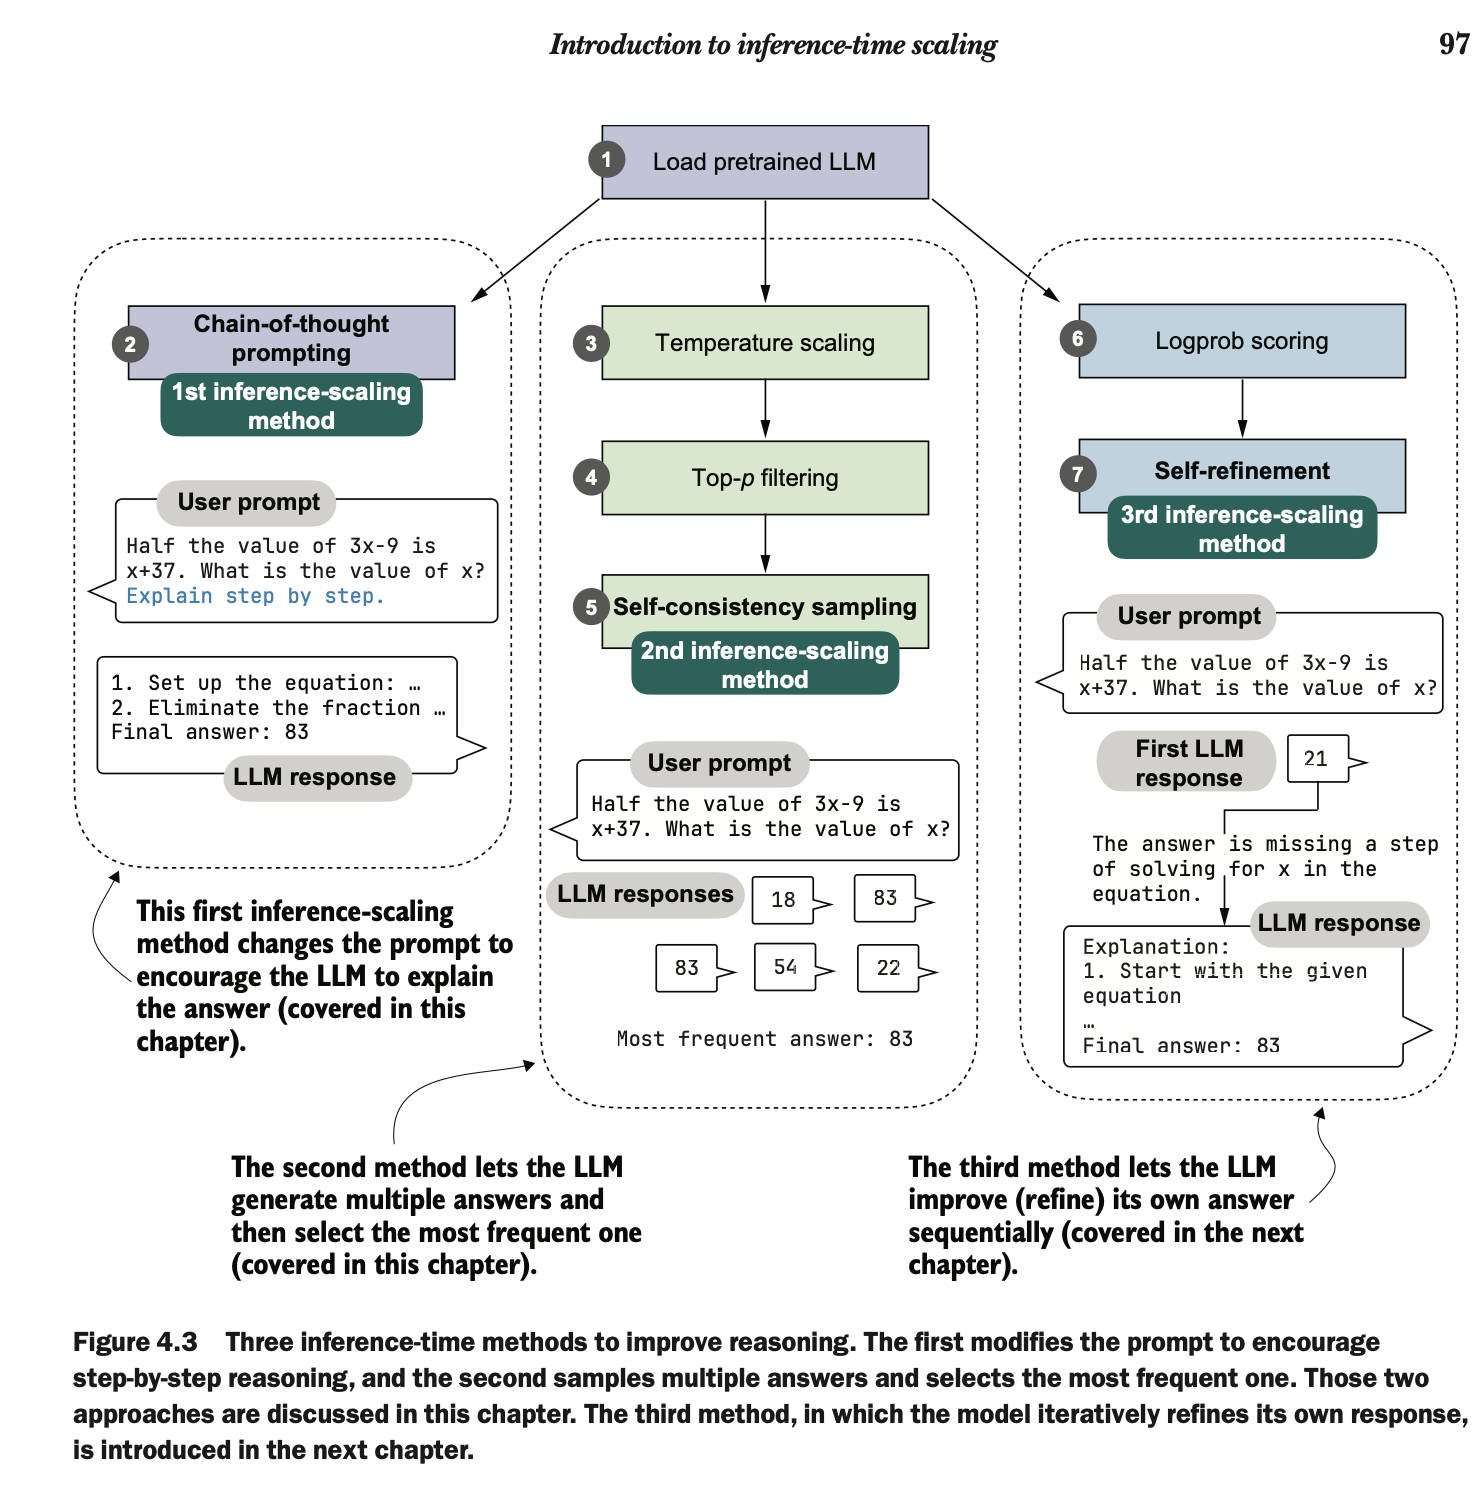


In [1]:
import torch
from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import load_model_and_tokenizer

device = get_device()
device = torch.device("cpu")

model, tokenizer = load_model_and_tokenizer(
    which_model="base", device=device, use_compile=False
)

In [2]:
# try the model on a prompt from the MATH-500 dataset, which we worked with
# in the previous chapter:

from reasoning_from_scratch.ch03 import render_prompt

raw_prompt = "Half the value of $3x-9$ is $x+37$. " "What is the value of $x$?"
prompt = render_prompt(raw_prompt)
print(prompt)

You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Answer:


In [4]:
from reasoning_from_scratch.ch02 import generate_text_basic_stream_cache


# We add parameters to accept a text generation
# function and additional arguments.
def generate_text_stream_concat_flex(
    model,
    tokenizer,
    prompt,
    device,
    max_new_tokens,
    verbose=False,
    generate_func=None,  # New
    **generate_kwargs  # New
):
    # if the text generation function is undefined,
    # we use generate_text_ basic_stream_cache similar to chapter 3.
    if generate_func is None:  # New
        generate_func = generate_text_basic_stream_cache

    input_ids = torch.tensor(tokenizer.encode(prompt), device=device).unsqueeze(0)

    generated_ids = []
    for token in generate_func(  # New
        model=model,
        token_ids=input_ids,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
        **generate_kwargs,  # New
    ):
        next_token_id = token.squeeze(0)
        generated_ids.append(next_token_id.item())

        if verbose:
            print(tokenizer.decode(next_token_id.tolist()), end="", flush=True)
    return tokenizer.decode(generated_ids)

In [5]:
response = generate_text_stream_concat_flex(
    model,
    tokenizer,
    prompt,
    device,
    max_new_tokens=2048,
    verbose=True,
    generate_func=generate_text_basic_stream_cache,
)

 \boxed{20}

# 4.3 Generating better responses with chain-of-thought prompting


In [6]:
prompt_cot = prompt + " \n\nExplain step by step."
response_cot = generate_text_stream_concat_flex(
    model,
    tokenizer,
    prompt_cot,
    device,
    max_new_tokens=2048,
    verbose=True,
)

 To solve the problem, we need to find the value of \( x \) such that half the value of \( 3x - 9 \) is equal to \( x + 37 \).

### Step 1: Set up the equation
We are given that half the value of \( 3x - 9 \) is equal to \( x + 37 \). This can be written as:
\[
\frac{1}{2}(3x - 9) = x + 37
\]

### Step 2: Eliminate the fraction
To eliminate the fraction, multiply both sides of the equation by 2:
\[
2 \cdot \frac{1}{2}(3x - 9) = 2(x + 37)
\]
Simplifying both sides:
\[
3x - 9 = 2x + 74
\]

### Step 3: Solve for \( x \)
Subtract \( 2x \) from both sides to isolate \( x \):
\[
3x - 2x - 9 = 74
\]
Simplify:
\[
x - 9 = 74
\]
Add 9 to both sides to solve for \( x \):
\[
x = 74 + 9
\]
\[
x = 83
\]

### Final Answer:
\[
\boxed{83}
\]

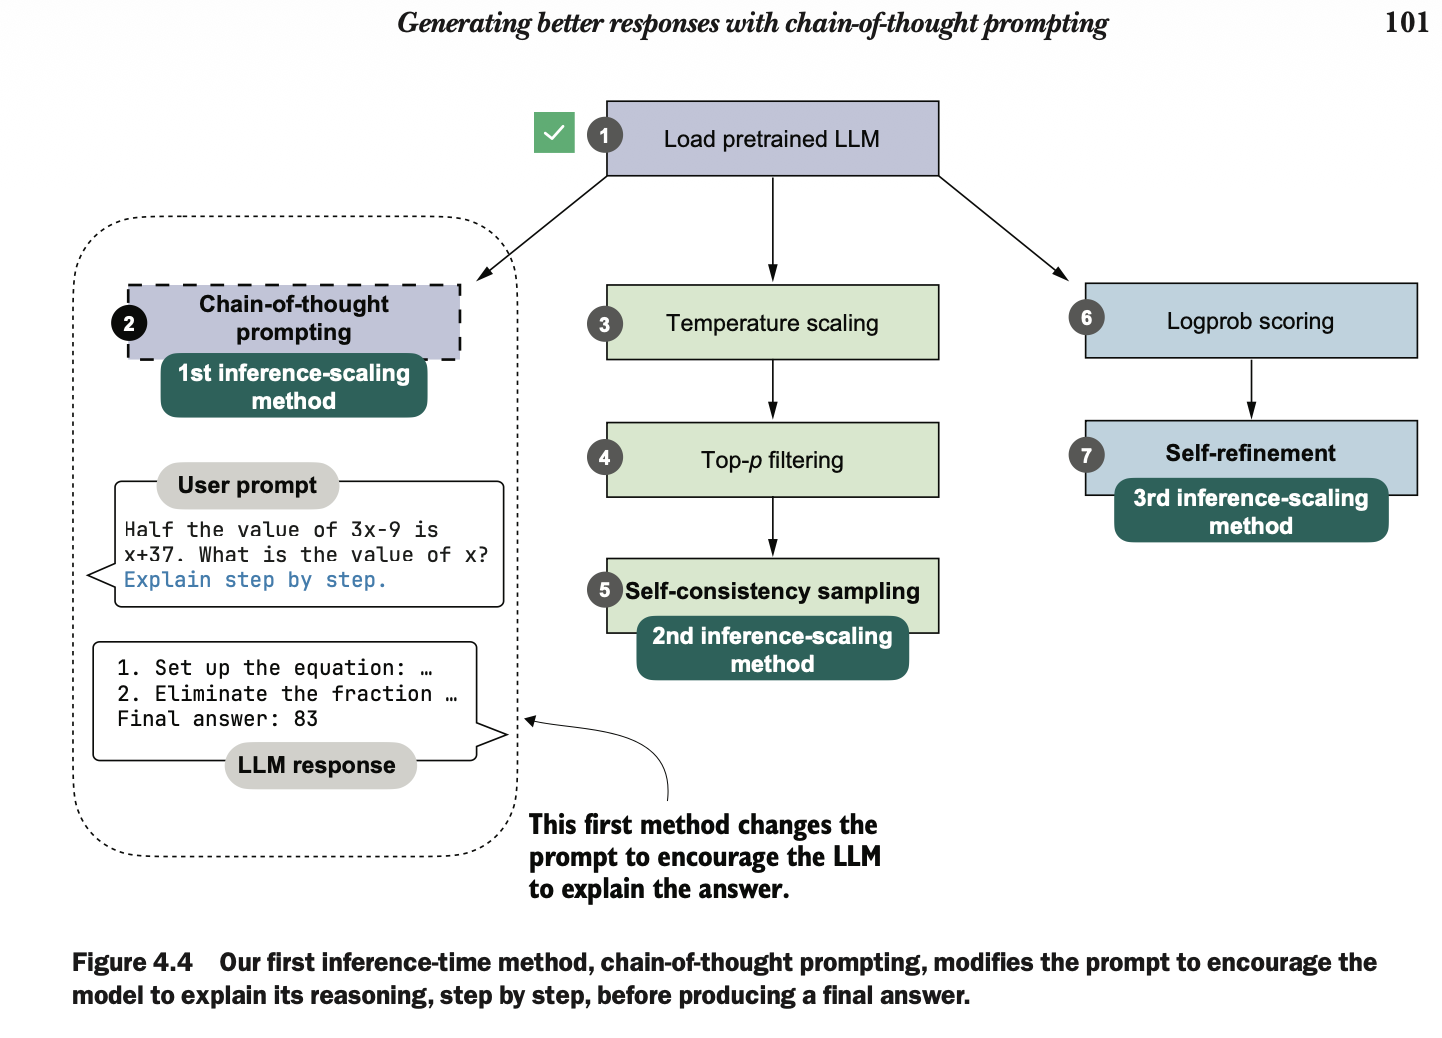


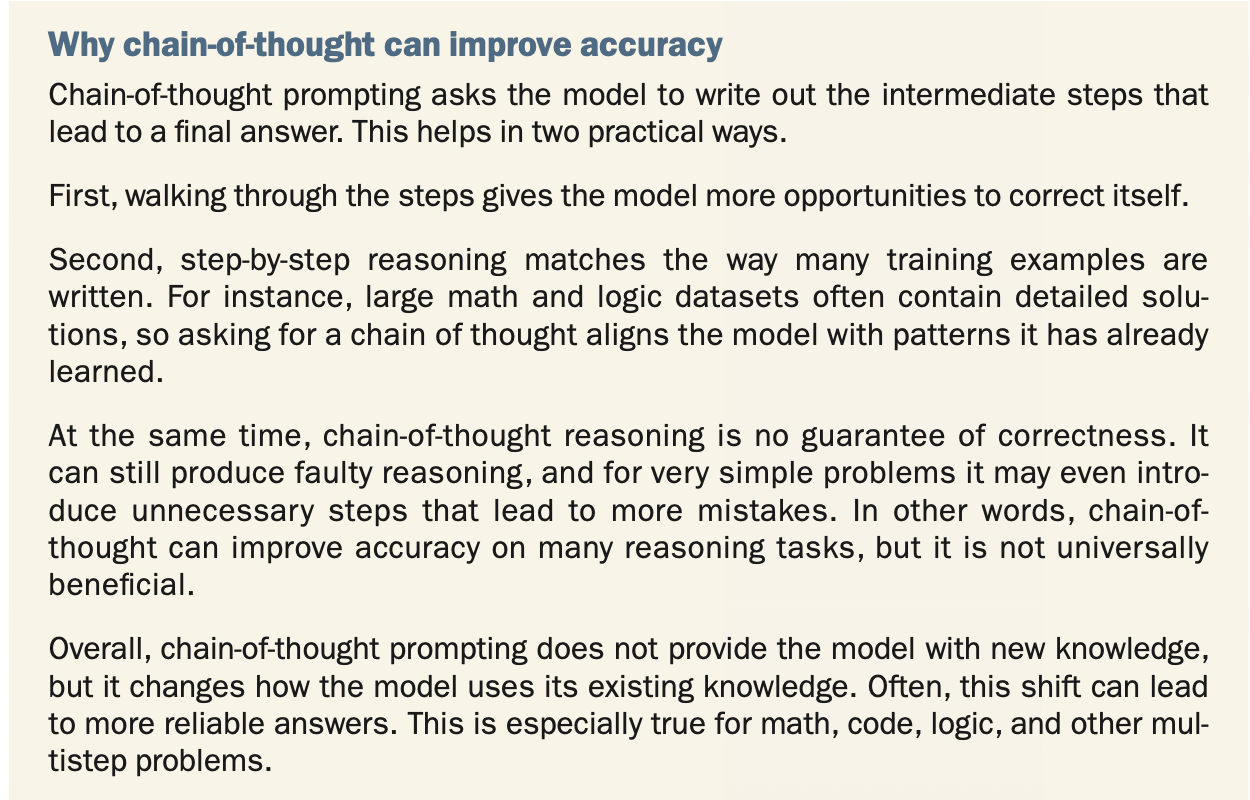


# 4.4 Controlling output diversity with temperature scaling

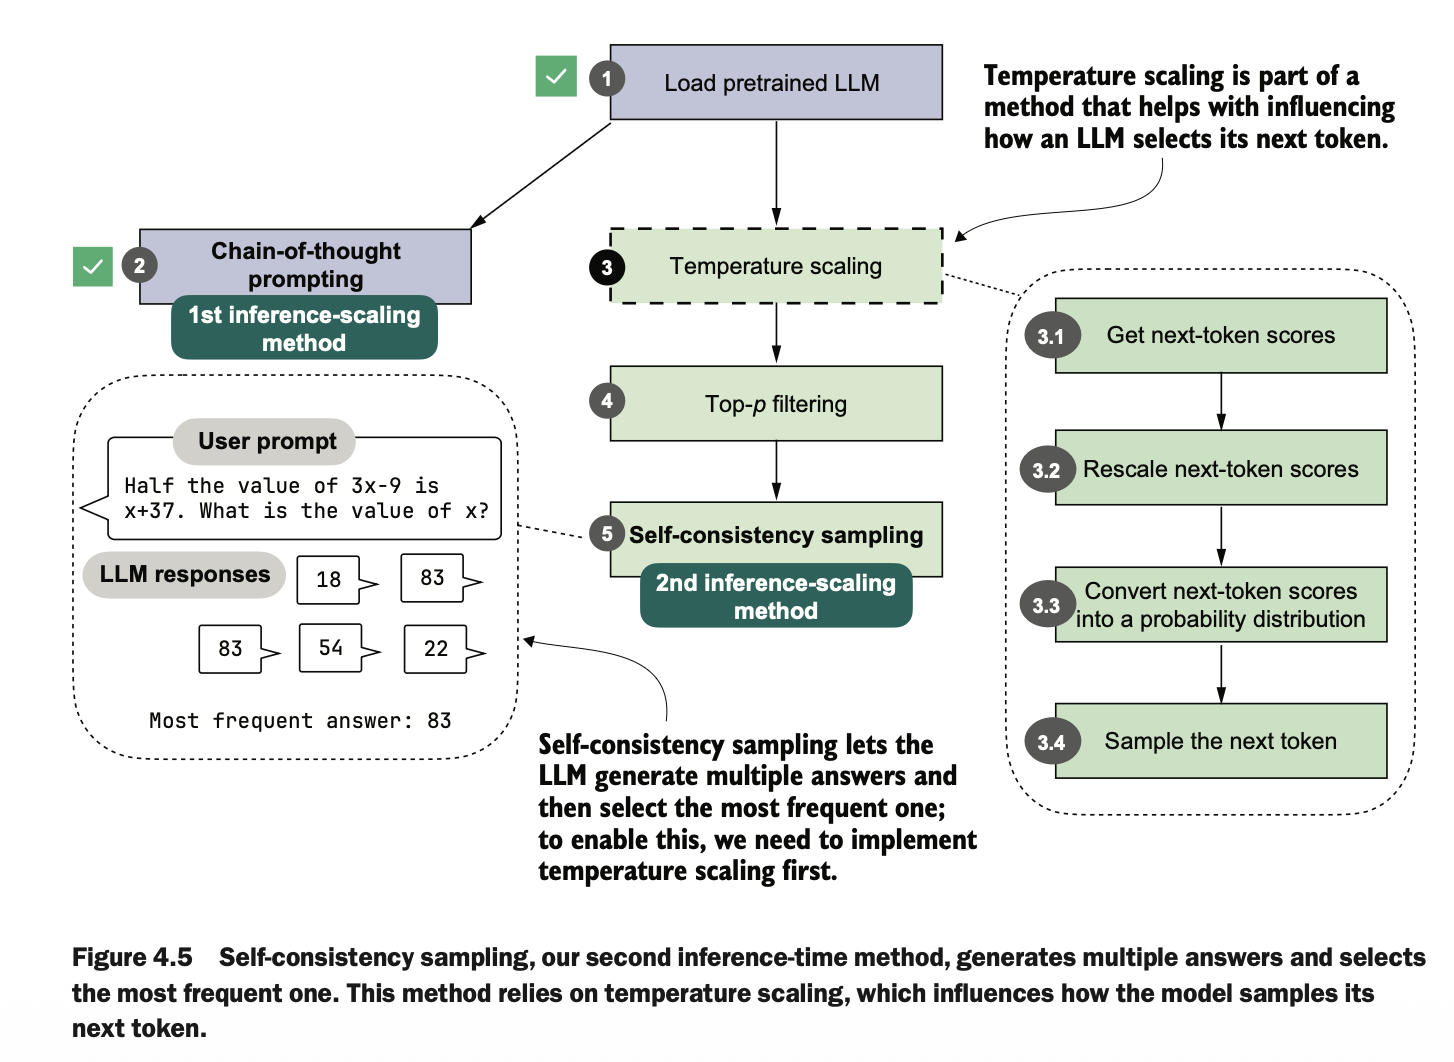


# 4.4.1 Understanding the process of selecting the next token


In [8]:
ex_prompt = "The capital of Germany is"
response = generate_text_stream_concat_flex(
    model, tokenizer, ex_prompt, device, max_new_tokens=1, verbose=True
)

 Berlin

In [9]:
# When generating text, the inputs are first converted into token IDs (as discussed in
# chapter 2):
input_token_ids = torch.tensor(tokenizer.encode(ex_prompt), device=device).unsqueeze(0)
print(input_token_ids)

tensor([[ 785, 6722,  315, 9856,  374]])


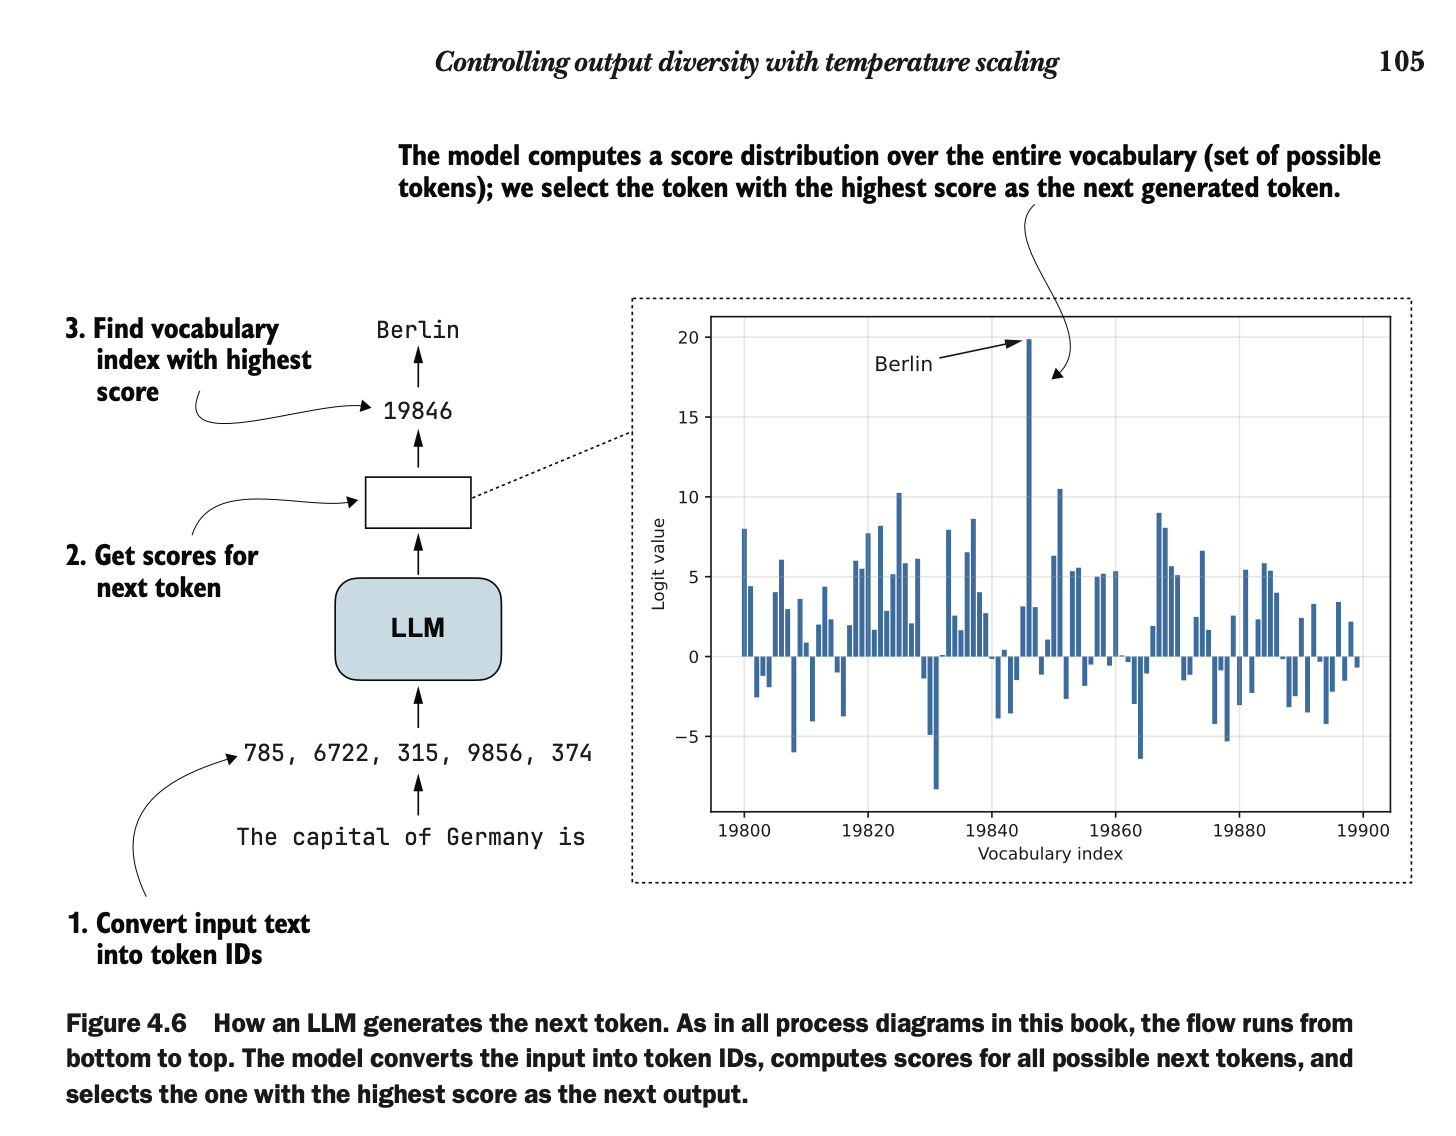


In [11]:
# 2) Get scores for next token

with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)  # Shape: [1, vocab_size]

torch.Size([1, 151936])


In [13]:
# To obtain the next generated token (" Berlin" in this example), we have to find the
# vocabulary entry associated with the largest score (step 3 in figure 4.6):

max_token_id = torch.argmax(next_token_logits)
print(f"Token ID: {max_token_id}")
print(f"Decoded token: '{tokenizer.decode([max_token_id])}'")

Token ID: 19846
Decoded token: ' Berlin'


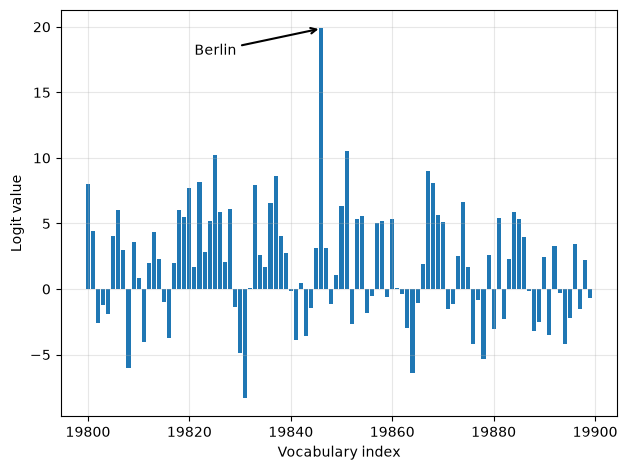

In [14]:
import matplotlib.pyplot as plt


def plot_scores_bar(
    next_token_logits, start=19_800, end=19_900, arrow=True, ylabel="Logit value"
):
    # Select vocabulary subsection
    x = torch.arange(start, end)

    # .cpu() is a shortcut for to(torch.device("cpu"))
    logits_section = next_token_logits[0, start:end].float().cpu()

    # Plot logits
    plt.bar(x, logits_section)
    plt.xlabel("Vocabulary index")
    plt.ylabel(ylabel)

    # Highlight max logit
    if arrow:
        max_idx = torch.argmax(logits_section)
        plt.annotate(
            "Berlin",
            xy=(x[max_idx], logits_section[max_idx]),
            xytext=(x[max_idx] - 25, logits_section[max_idx] - 2),
            arrowprops={"facecolor": "black", "arrowstyle": "->", "lw": 1.5},
            fontsize=10,
        )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_scores_bar(next_token_logits)

# 4.4.2 Rescaling token scores (logits) via a temperature parameter


In [ ]:
# Listing 4.4 Rescaling next-token scores via temperature scaling


def scale_logits_by_temperature(logits, temperature):
    if temperature <= 0:
        raise ValueError("Temperature must be positive")
    return logits / temperature

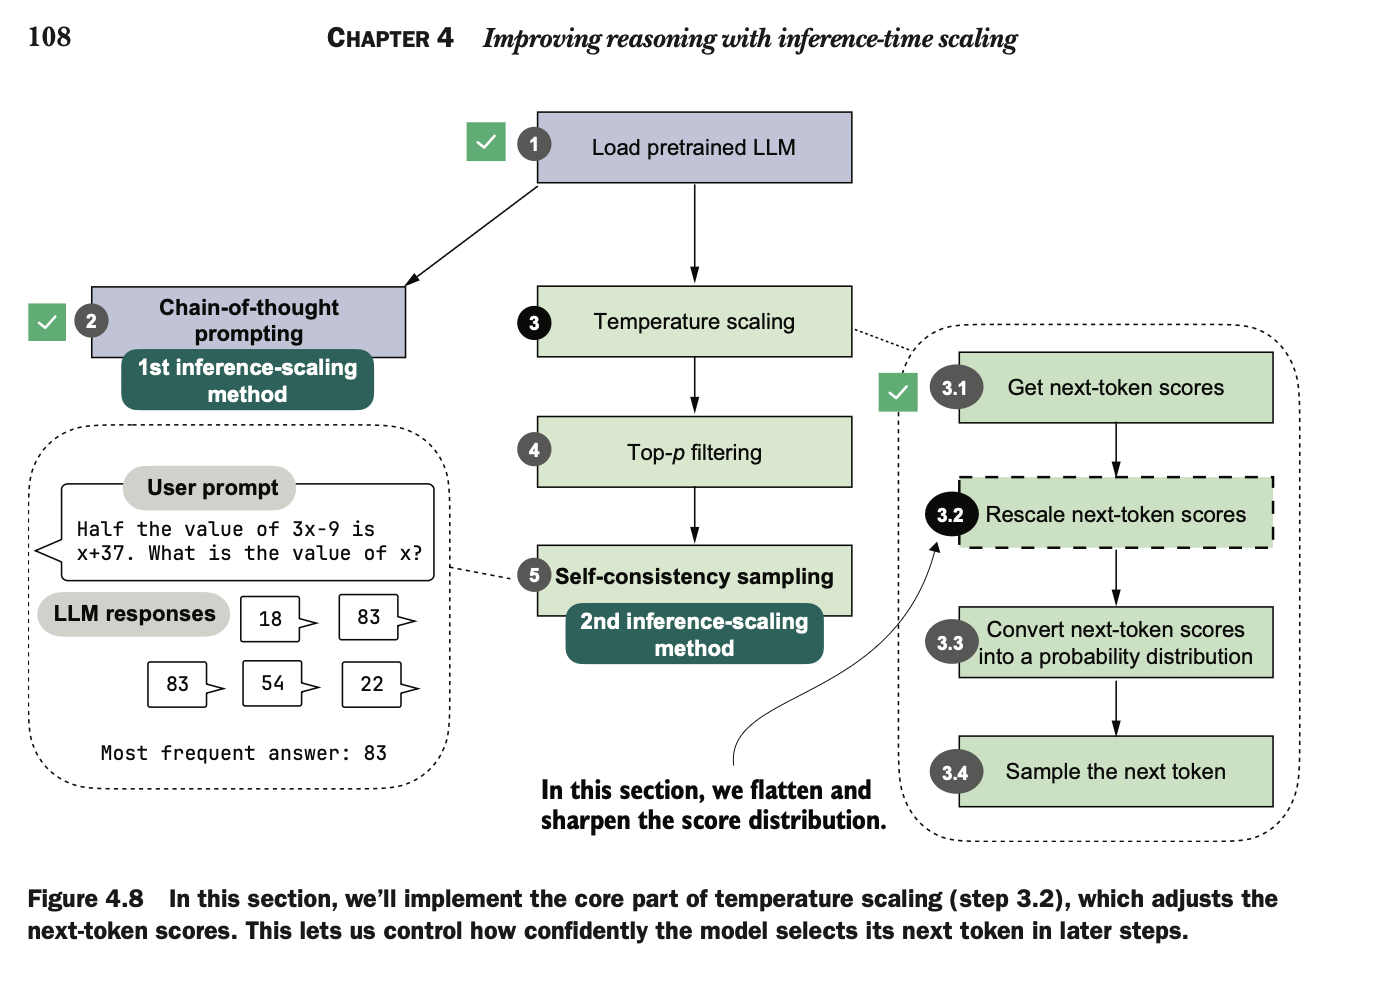


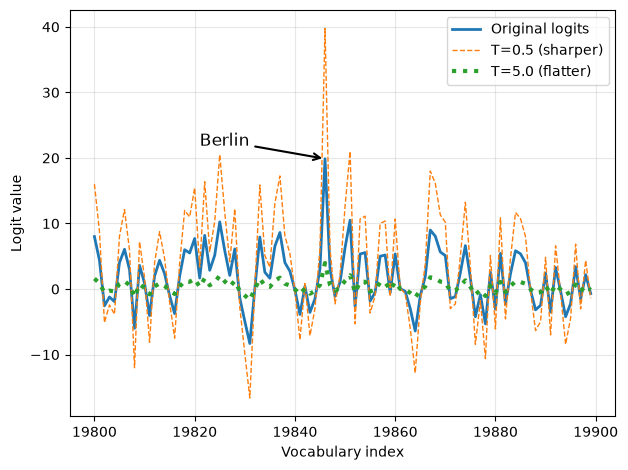

In [16]:
def plot_logits_with_temperature(
    next_token_logits,
    start=19_800,
    end=19_900,
    temps=(0.5, 5.0),
):
    x = torch.arange(start, end)
    logits_orig = next_token_logits[0, start:end].float().cpu()

    # Apply temperature scaling
    logits_scaled = [scale_logits_by_temperature(logits_orig, T) for T in temps]
    # Plot logits
    plt.plot(x, logits_orig, label="Original logits", lw=2)
    plt.plot(x, logits_scaled[0], label=f"T={temps[0]} (sharper)", ls="--", lw=1)
    plt.plot(x, logits_scaled[1], label=f"T={temps[1]} (flatter)", ls=":", lw=3)

    # Highlight max logit
    max_idx = torch.argmax(logits_orig)
    plt.annotate(
        "Berlin",
        xy=(x[max_idx], logits_orig[max_idx]),
        xytext=(x[max_idx] - 25, logits_orig[max_idx] + 2),
        arrowprops={"facecolor": "black", "arrowstyle": "->", "lw": 1.5},
        fontsize=12,
    )

    plt.xlabel("Vocabulary index")
    plt.ylabel("Logit value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_logits_with_temperature(next_token_logits, temps=(0.5, 5.0))

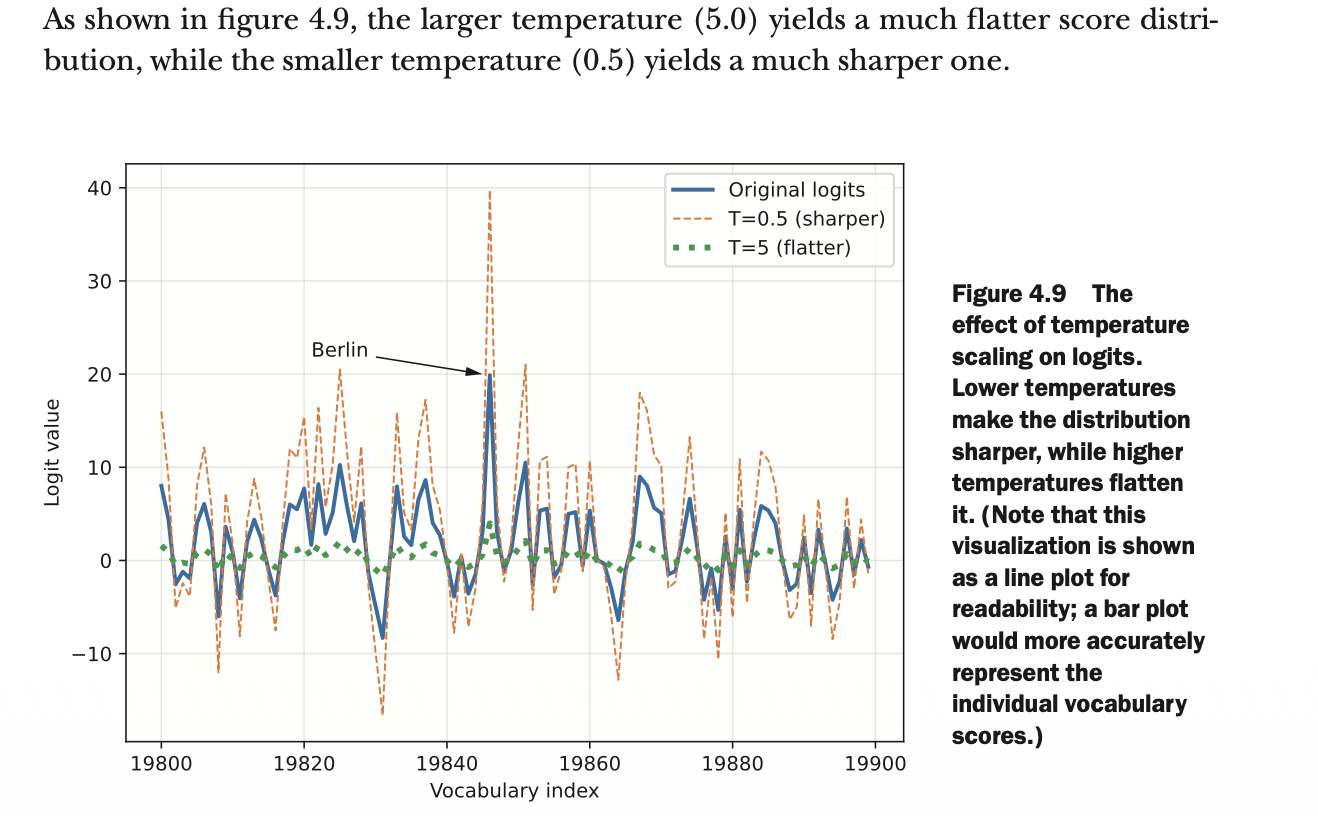
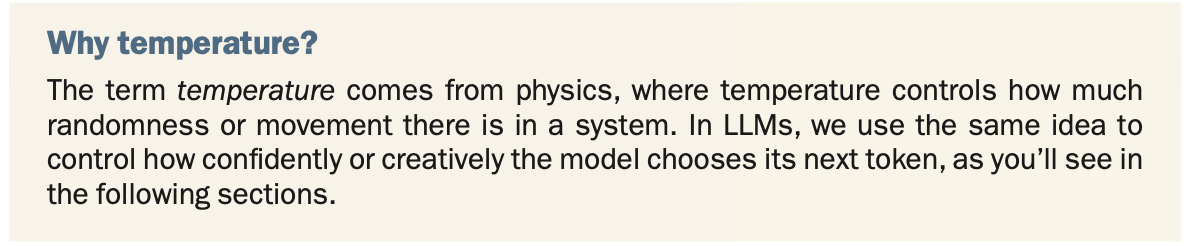


# 4.4.3 Sampling the next token from a probability distribution


In [17]:
# Step 3.2: Rescale next-token scores
rescaled_logits = scale_logits_by_temperature(next_token_logits, 5.0)

# Step 3.3 Convert rescaled logits into probability scores
next_token_probas = torch.softmax(rescaled_logits, dim=-1)

print("Probability sum:", torch.sum(next_token_probas))

Probability sum: tensor(1., dtype=torch.bfloat16)


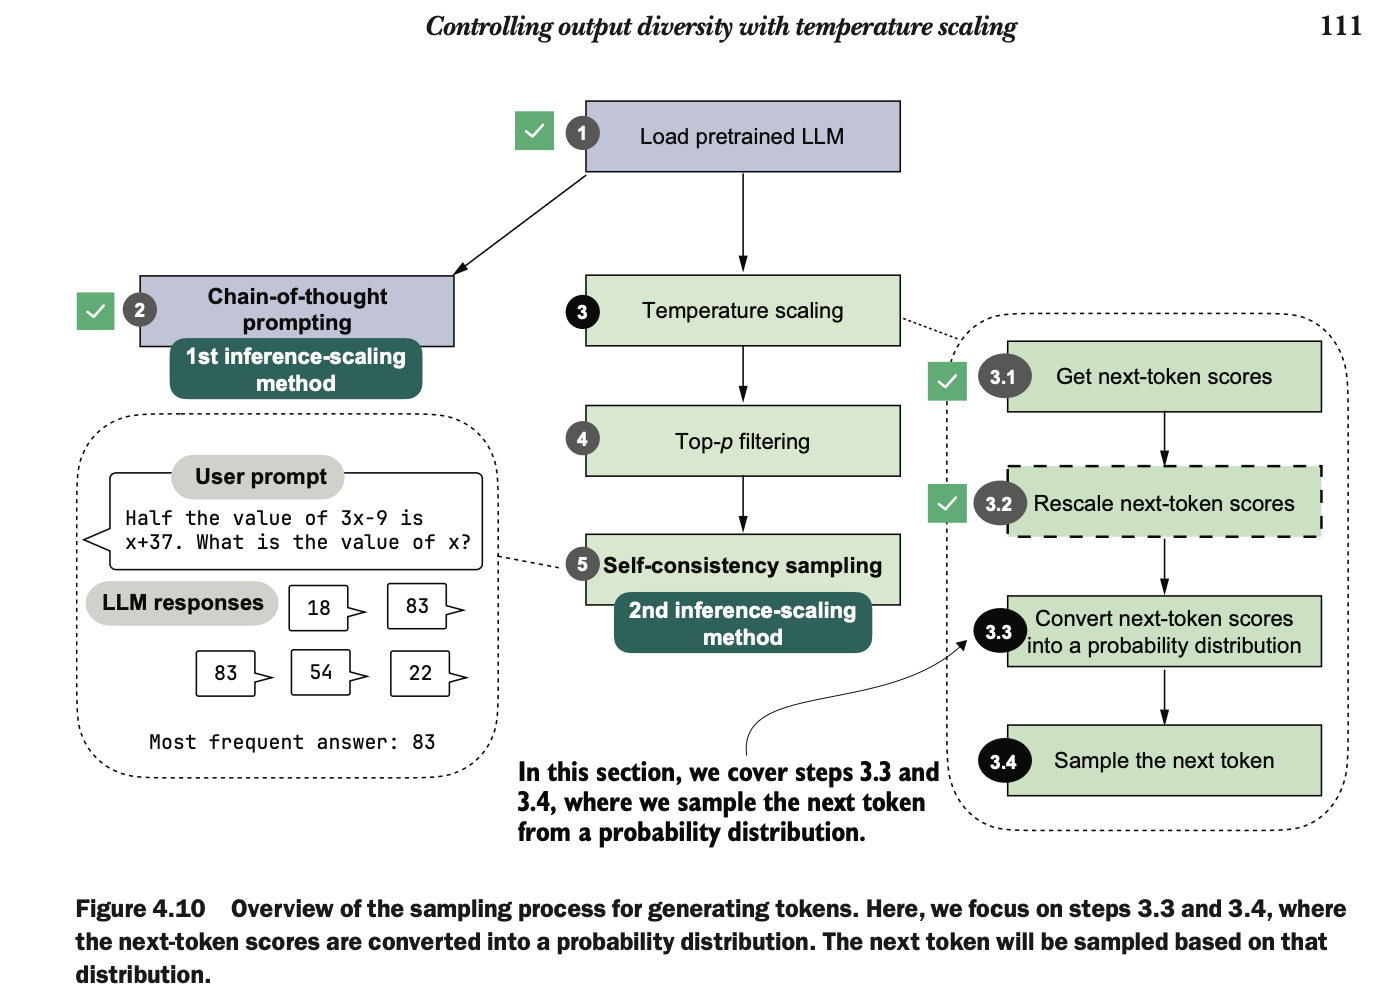


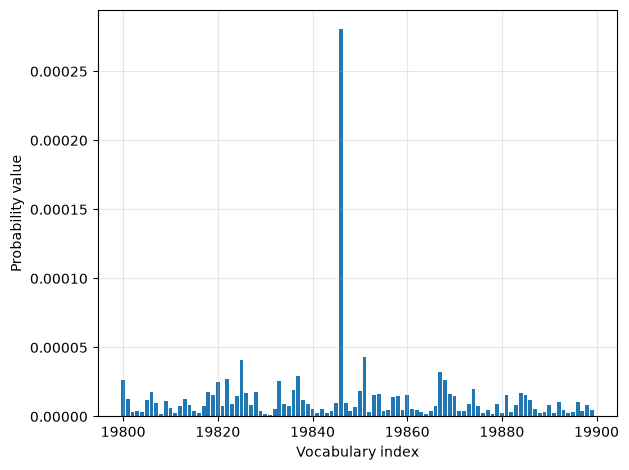

In [19]:
# Additionally, let’s visualize the converted scores by reusing the plot_scores_bar func-
# tion from listing 4.3:
plot_scores_bar(next_token_probas, arrow=False, ylabel="Probability value")

In [21]:
print("Token ID 19,846 probability:", next_token_probas[:, 19846])

Token ID 19,846 probability: tensor([0.0003], dtype=torch.bfloat16)


In [24]:
print("Highest probability:", max(next_token_probas.squeeze(0)))

Highest probability: tensor(0.0003, dtype=torch.bfloat16)


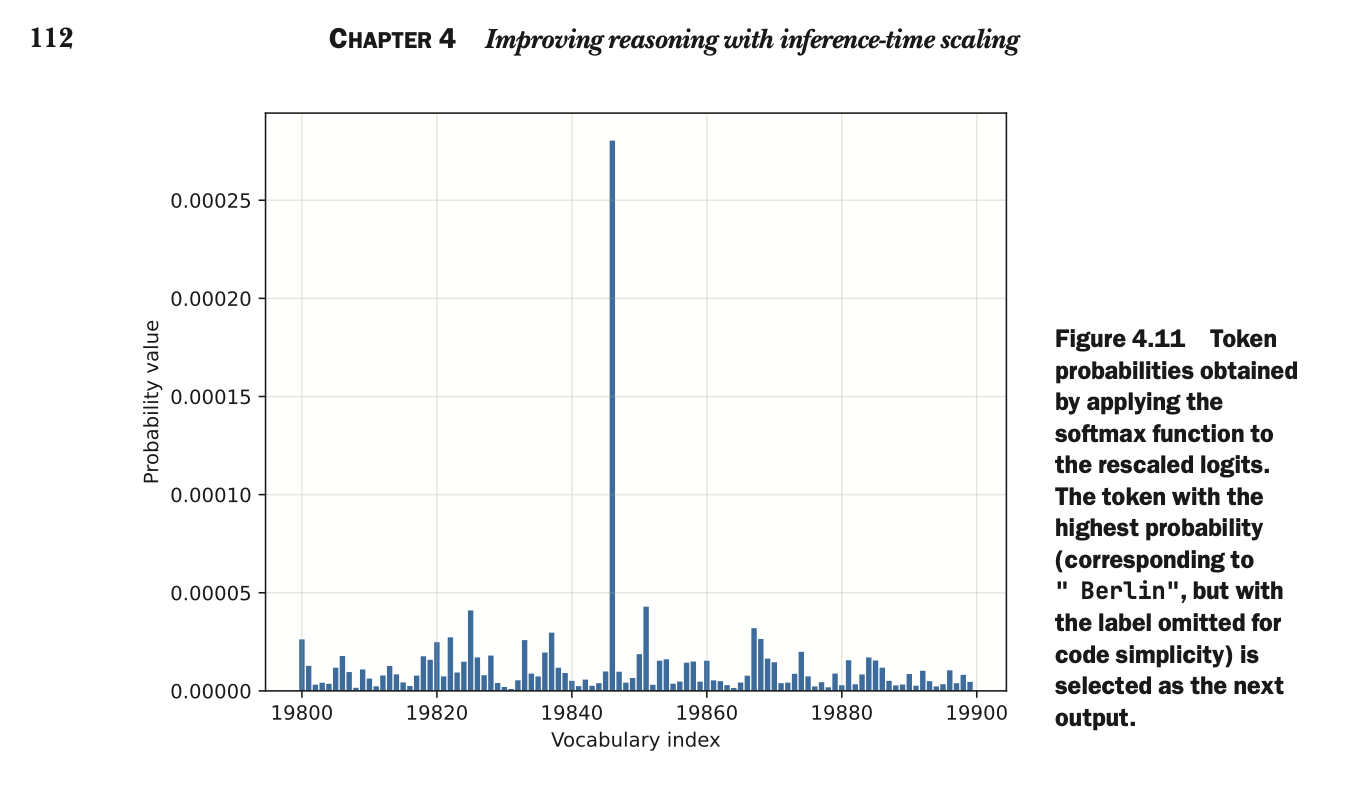


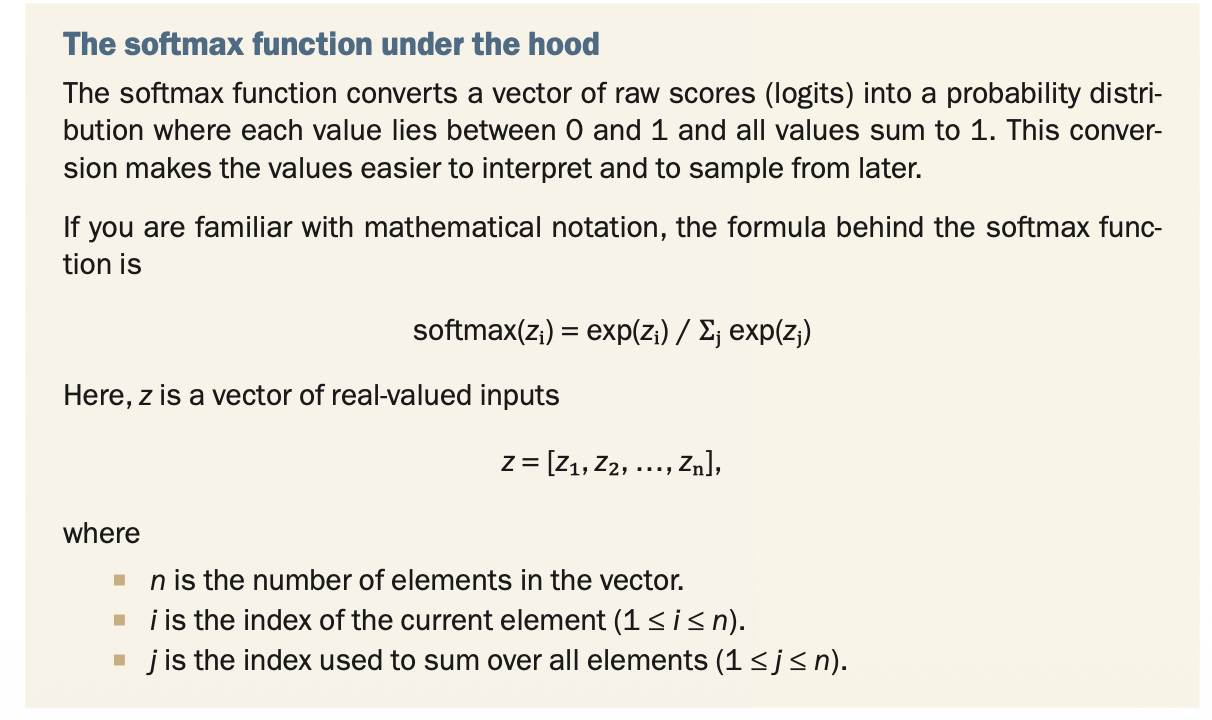
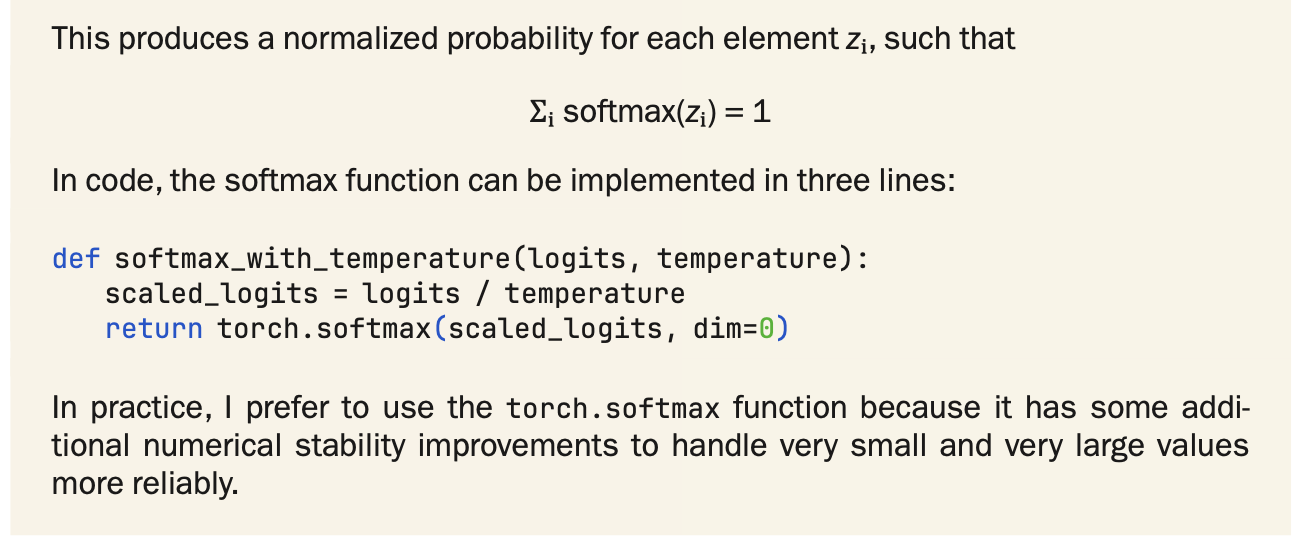


In [26]:
# The sampling process, corresponding to step 3.4 in figure 4.10, can be implemented
# as follows:

torch.manual_seed(123)
print("Sampled token:", torch.multinomial(next_token_probas.cpu(), num_samples=1))

Sampled token: tensor([[65094]])


In [28]:
# Listing 4.7 Sampling multiple next-token candidates


def count_samples(probas, num_samples=1000, threshold=1, tokenizer=None):

    # Draw samples according to probabilities
    samples = torch.multinomial(probas.cpu(), num_samples=num_samples, replacement=True)

    # Count how often each index was selected
    counts = torch.bincount(samples.squeeze(0), minlength=1)

    # Print results
    for i, c in enumerate(counts):
        if c > threshold:
            if tokenizer is None:
                print(f"Vocab index {i}: {c.item()}x")
            else:
                print(f"'{tokenizer.decode([i])}': {c.item()}x")

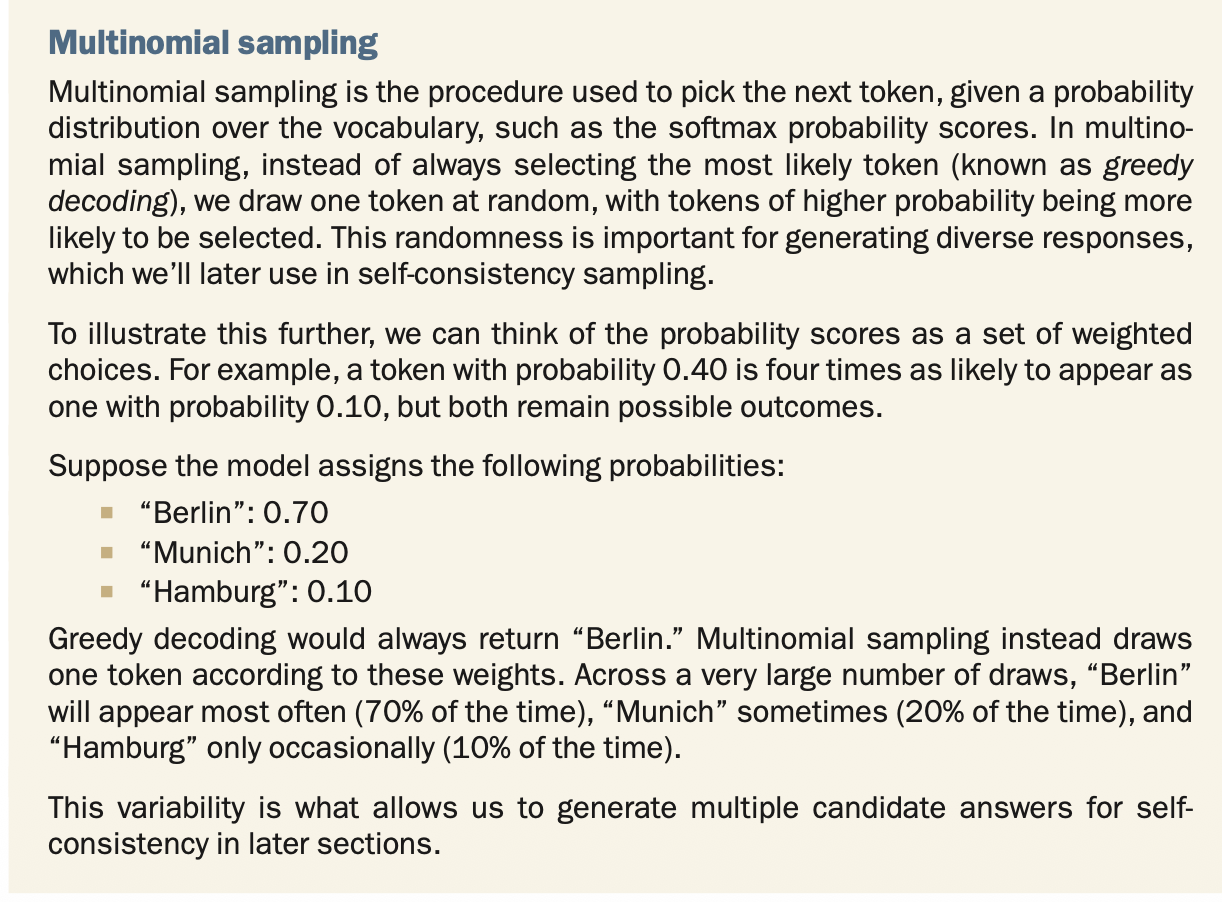


In [30]:
# First, let’s run the count_samples function on the probability scores that we obtained
# by applying a temperature of 5:

torch.manual_seed(123)
count_samples(next_token_probas, tokenizer=tokenizer)

'}': 2x
' </': 2x
' represent': 2x
' Inf': 2x
'()*': 2x
' beside': 2x
' Kob': 2x
'�': 2x


In [35]:
# Let’s try a lower temperature value of 0.35, which sharpens the score distribution
# and makes it more likely to select a meaningful next token:

torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, tokenizer=tokenizer)

print("\n", probas_lowT[0, 19_846])

' __': 158x
' Berlin': 435x
' ____': 169x
' ______': 209x
' Munich': 3x
' Hamburg': 3x
' _____': 18x

 tensor(0.4199, dtype=torch.bfloat16)


# 4.4.4 Adding temperature scaling to the text generation function


In [ ]:
# Listing 4.8 Text generation with temperature scaling
# Exercise 2.2 Appendix B
from reasoning_from_scratch.qwen3 import KVCache


@torch.inference_mode()
def generate_text_temp_stream_cache(
    model, token_ids, max_new_tokens, eos_token_id=None, temperature=0.0
):
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()

    # Step 3.1: Get logits
    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):

        ########################################
        # NEW:
        orig_device = token_ids.device

        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)

        else:
            # Step 3.2: Apply temperature scaling on logits
            logits = scale_logits_by_temperature(out, temperature)

            # Step 3.3: Convert to probabilities
            probas = torch.softmax(logits, dim=-1)

            # Step 3.4: Sample token according to probabilities
            next_token = torch.multinomial(probas.cpu(), num_samples=1)
            next_token = next_token.to(orig_device)

        #########################################
        if eos_token_id is not None and torch.all(next_token == eos_token_id):
            break

        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [37]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model,
    tokenizer,
    prompt,
    device,
    max_new_tokens=2048,
    verbose=True,
    generate_func=generate_text_temp_stream_cache,
    temperature=1.1,
)

 \boxed{$x = \frac{90}{7}$}

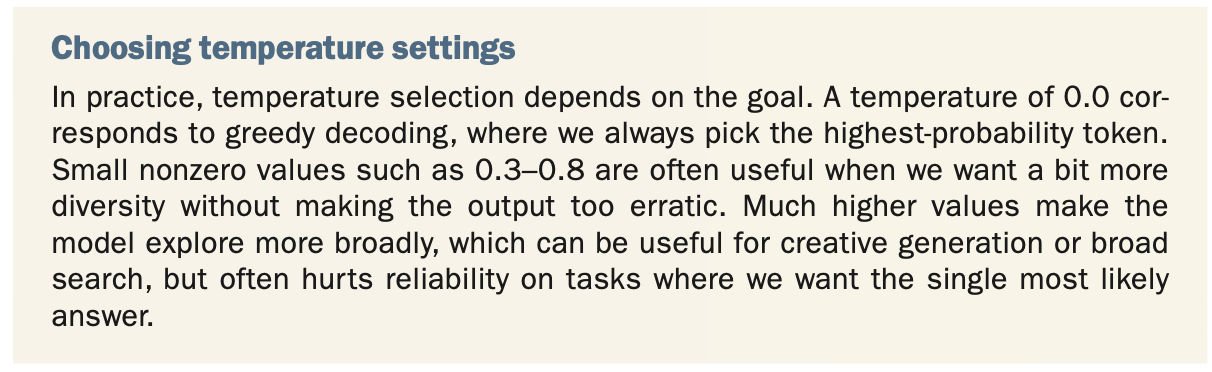


# 4.5 Balancing diversity and coherence with top-p sampling

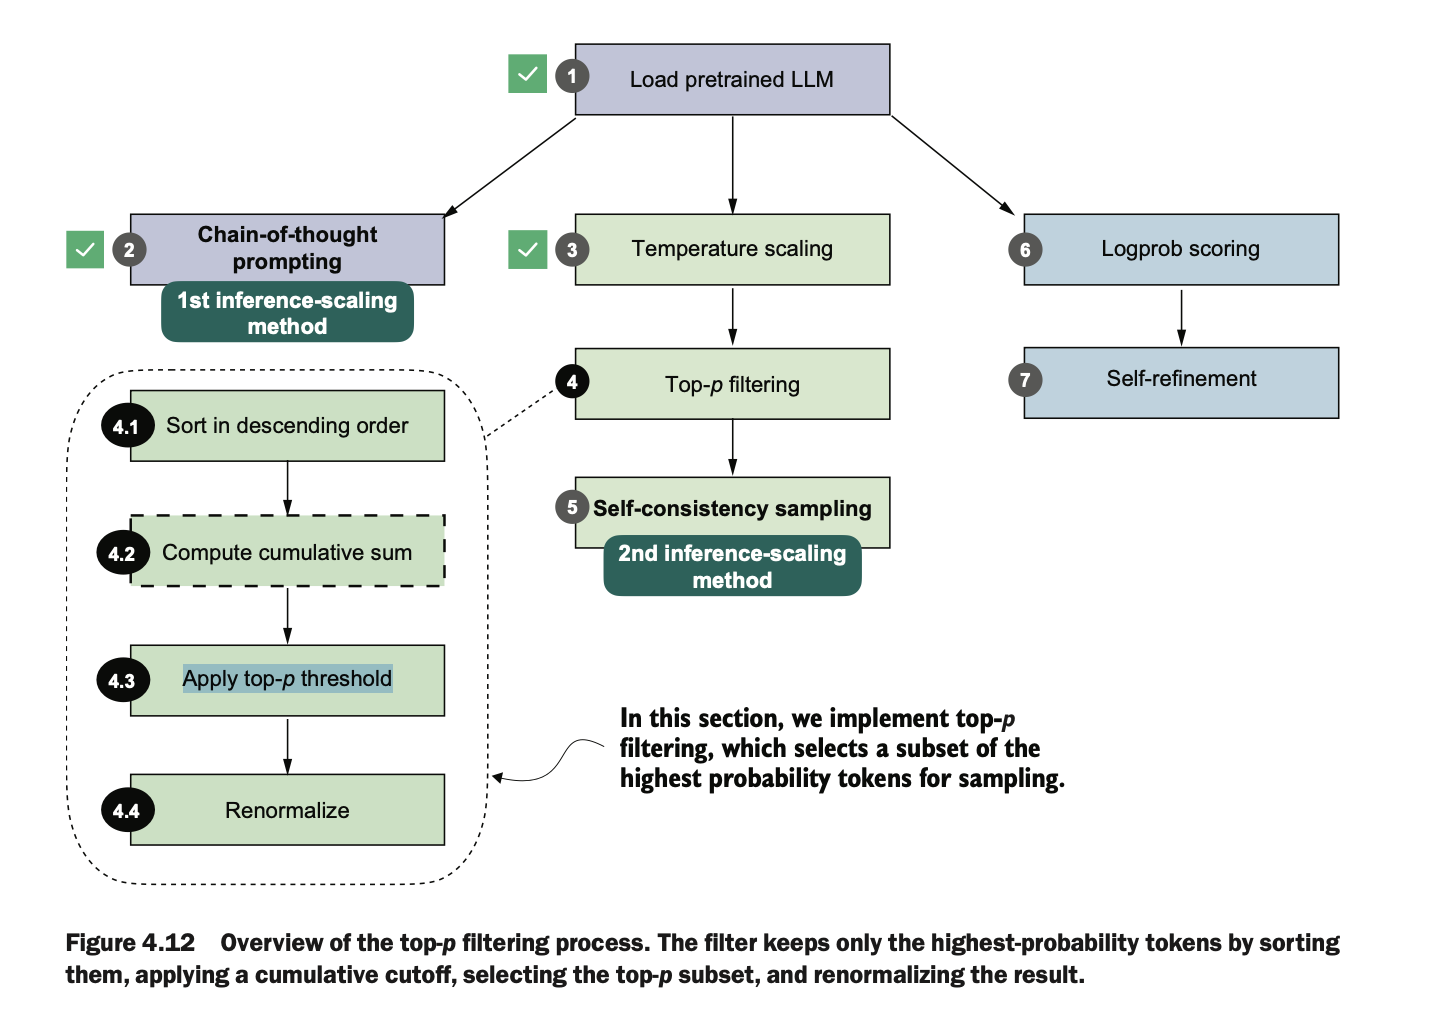


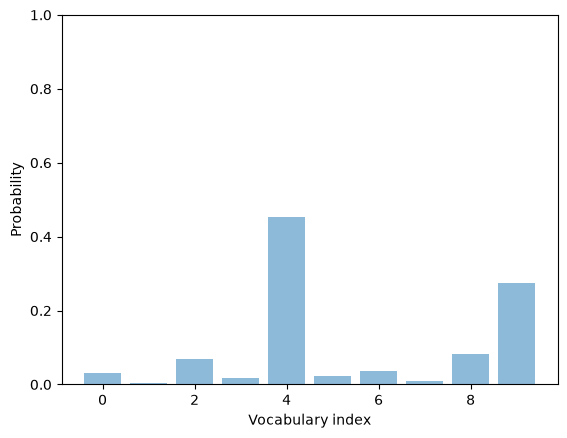

In [39]:
# Listing 4.9 Temperature scaling and sampling with toy data

# Step 3.1: Get logits (here: use toy logits for 10 tokens)
toy_logits = torch.tensor([-0.7, -3.0, 0.1, -1.2, 2.0, -1.0, -0.5, -2.0, 0.3, 1.5])

# Step 3.2: Apply temperature scaling
toy_logits_scaled = scale_logits_by_temperature(toy_logits, 1.0)

# Step 3.3: Convert to probabilities
toy_probas = torch.softmax(toy_logits_scaled, dim=-1)

plt.bar(torch.arange(len(toy_logits_scaled)), toy_probas, alpha=0.5)

plt.ylim([0, 1])
plt.xlabel("Vocabulary index")
plt.ylabel("Probability")
# plt.savefig("12.pdf")
plt.show()

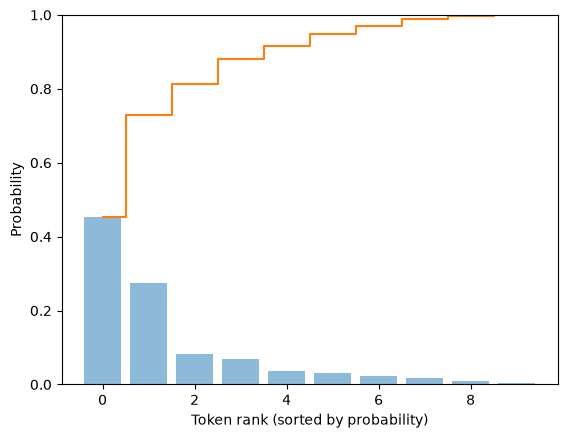

In [43]:
# Step 4.1: Sort by descending probability
sorted_probas, sorted_idx = torch.sort(toy_probas, descending=True)

# Step 4.2: Compute cumulative sum
cumsum = torch.cumsum(sorted_probas, dim=-1)

plt.bar(torch.arange(len(sorted_probas)), sorted_probas, alpha=0.5)
plt.step(
    torch.arange(len(cumsum)), cumsum, where="mid", color="C1", label="Cumulative sum"
)

plt.ylim([0, 1])
plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.show()

In [45]:
# Listing 4.11 A simple-top-p filtering rule

# Step 4.3.1: Apply top-p threshold (e.g., keep tokens until cumulative mass > 0.8)
top_p = 0.8
keep_mask = cumsum <= top_p
n_kept = torch.sum(keep_mask).item()
print("Cumulative sum:", cumsum)
print("Tokens kept:", n_kept)

Cumulative sum: tensor([0.4538, 0.7290, 0.8119, 0.8798, 0.9170, 0.9475, 0.9701, 0.9886, 0.9969,
        1.0000])
Tokens kept: 2


In [47]:
# Listing 4.12 A common top-p filtering variant

# A more common variant is to include the token that crosses the threshold
keep_mask = (cumsum - sorted_probas) < top_p
n_kept = keep_mask.sum().item()
print("Tokens kept : ", n_kept)

Tokens kept :  3


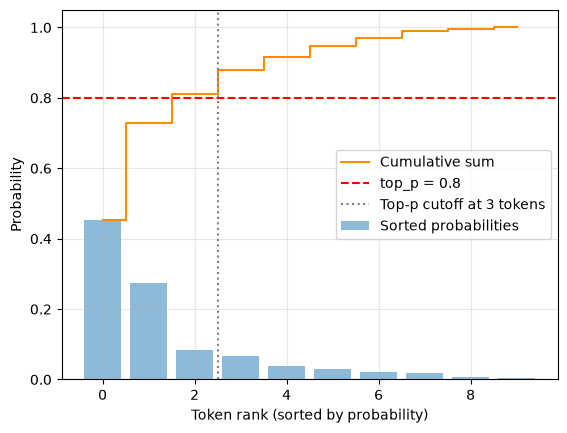

In [48]:
# Listing 4.13 Visualizing top-p filtering

plt.bar(
    torch.arange(len(sorted_probas)),
    sorted_probas,
    alpha=0.5,
    label="Sorted probabilities",
)
plt.step(
    torch.arange(len(cumsum)),
    cumsum,
    where="mid",
    color="darkorange",
    label="Cumulative sum",
)

# Highlight cutoff
plt.axhline(top_p, color="red", linestyle="--", label=f"top_p = {top_p}")
plt.axvline(
    n_kept - 0.5, color="gray", linestyle=":", label=f"Top-p cutoff at {n_kept} tokens"
)

plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
# plt.savefig("14.pdf")
plt.show()

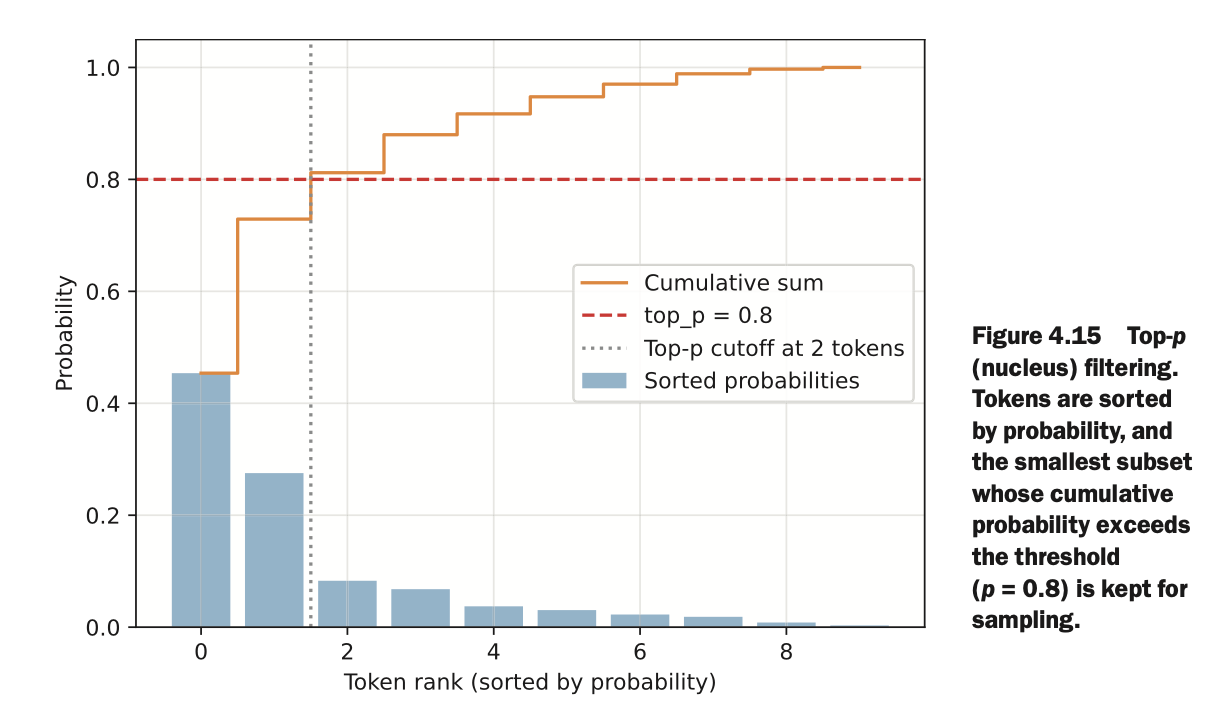


In [52]:
# Listing 4.14 Applying top-p filtering

kept_sorted = torch.where(keep_mask, sorted_probas, torch.zeros_like(sorted_probas))

filtered = torch.zeros_like(toy_probas).scatter(0, sorted_idx, kept_sorted)
print(filtered)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.4538, 0.0000, 0.0000, 0.0000, 0.0829,
        0.2752])


In [53]:
# Finally, we renormalize these values so that they sum to one again:

denom = torch.sum(filtered).clamp_min(1e-12)
renormalized = filtered / denom
print(renormalized)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.5589, 0.0000, 0.0000, 0.0000, 0.1021,
        0.3390])


- The goal of this top-p filtering is to remove tokens with low probabilities so they aren’t sampled later. This helps reduce nonsensical token responses in a given context.


# 4.5.2 Adding a top-p filter to the text generation function


In [ ]:
# Top-p filtering functionx


def top_p_filter(probas, top_p):
    if top_p is None or top_p >= 1.0:
        return probas

    # Step 4.1: Sort by descending probability
    sorted_probas, sorted_idx = torch.sort(probas, dim=1, descending=True)

    # Step 4.2: Cumulative sum
    cumprobas = torch.cumsum(sorted_probas, dim=1)

    # Step 4.3.1: Keep tokens where prefix cumulative mass (before token) is < top_p
    # Example: [0.5, 0.41, 0.09] with top_p=0.9 should keep the first two tokens
    prefix = cumprobas - sorted_probas  # cumulative mass before each token
    keep = prefix < top_p
    # Always keep at least one token (fallback for very small/non-positive top_p)
    keep[:, 0] = True

    # Step 4.3.2: Zero out beyond cutoff
    kept_sorted = torch.where(keep, sorted_probas, torch.zeros_like(sorted_probas))

    # Step 4.3.3: Map back to original order
    filtered = torch.zeros_like(probas).scatter(1, sorted_idx, kept_sorted)

    # Step 4.4: Renormalize to sum to 1
    denom = torch.sum(filtered, dim=1, keepdim=True).clamp_min(1e-12)
    return filtered / denom

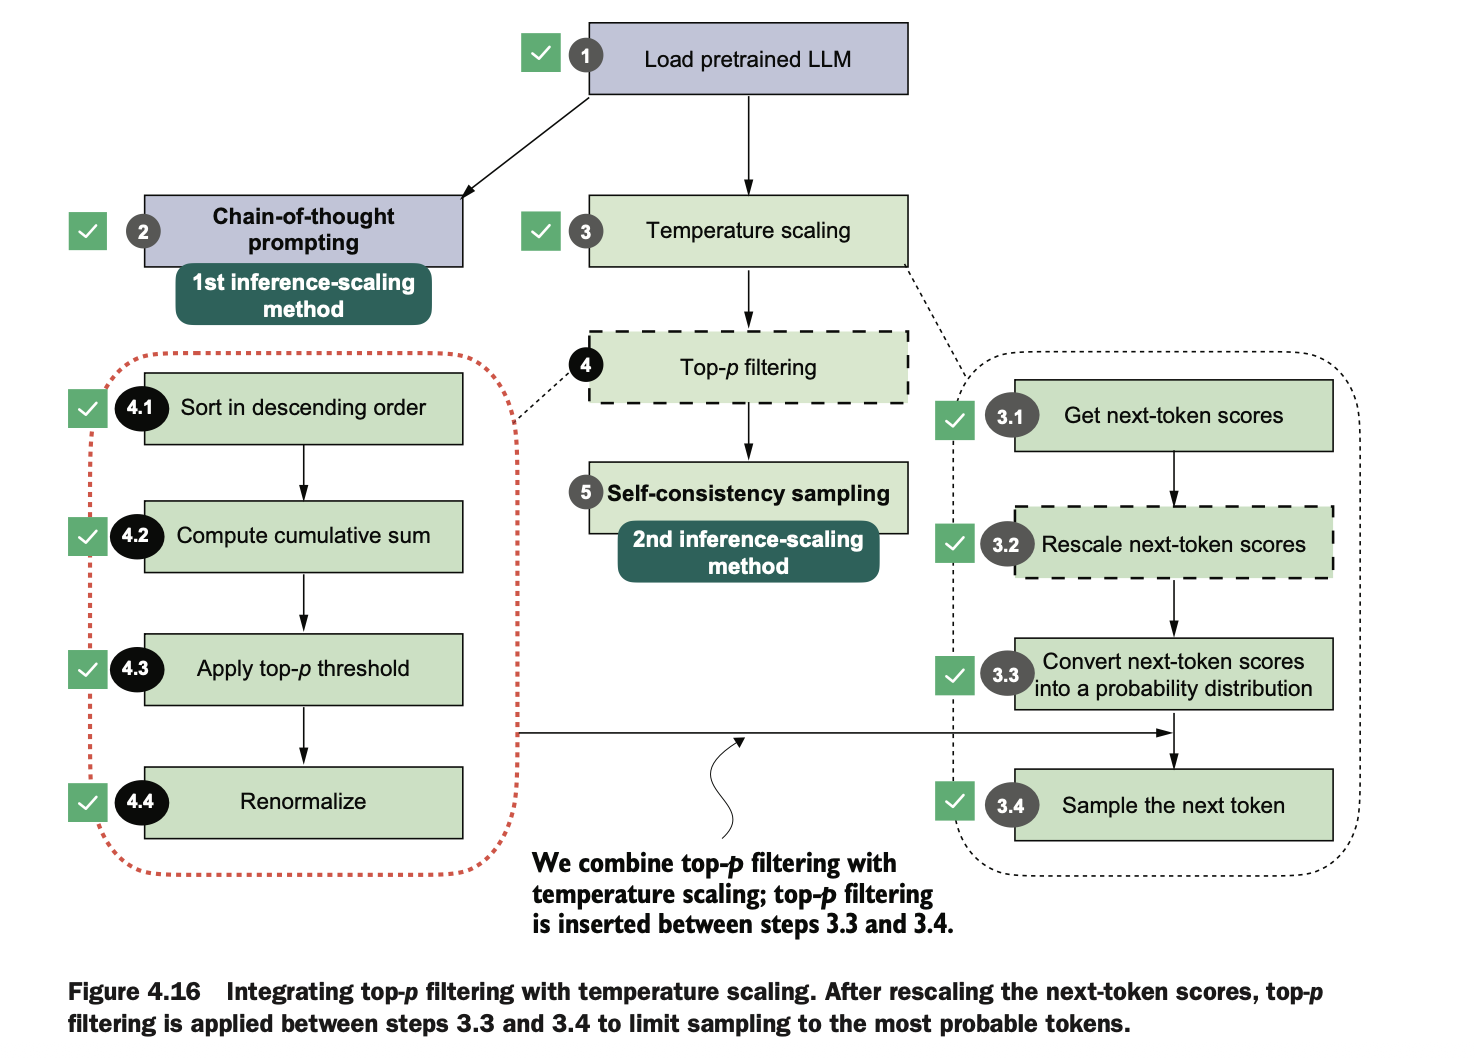


In [57]:
with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)

torch.Size([1, 151936])


In [59]:
# Next, we rescale the logits into probability scores
# and apply temperature scaling with a temperature of 0.35, as before:

torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

' __': 158x
' Berlin': 435x
' ____': 169x
' ______': 209x
' Munich': 3x
' Hamburg': 3x
' _____': 18x


In [61]:
# Now, let’s add the top-p filter and see how it changes the results:

torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
probas_lowT_filtered = top_p_filter(probas_lowT, top_p=0.8)
count_samples(probas_lowT_filtered, threshold=1, tokenizer=tokenizer)

' Berlin': 534x
' ____': 217x
' ______': 249x


In [62]:
# Listing 4.16 Text generation with top-p filtering


@torch.inference_mode()
def generate_text_top_p_stream_cache(
    model, token_ids, max_new_tokens, eos_token_id=None, temperature=0.0, top_p=None
):
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()

    # Step 3.1: Get logits
    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):

        orig_device = token_ids.device

        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)

        else:
            # Step 3.2: Apply temperature scaling on logits
            logits = scale_logits_by_temperature(out, temperature)

            # Step 3.3: Convert to probabilities
            probas = torch.softmax(logits, dim=-1)

            # (New) Step 4: Apply top-p filter to probabilities
            probas = top_p_filter(probas, top_p)

            # Step 3.4: Sample token according to probabilities
            next_token = torch.multinomial(probas.cpu(), num_samples=1)
            next_token = next_token.to(orig_device)

        if eos_token_id is not None and torch.all(next_token == eos_token_id):
            break

        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [63]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model,
    tokenizer,
    prompt,
    device,
    max_new_tokens=2048,
    verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.5,
    top_p=0.8,
)

 \boxed{18}

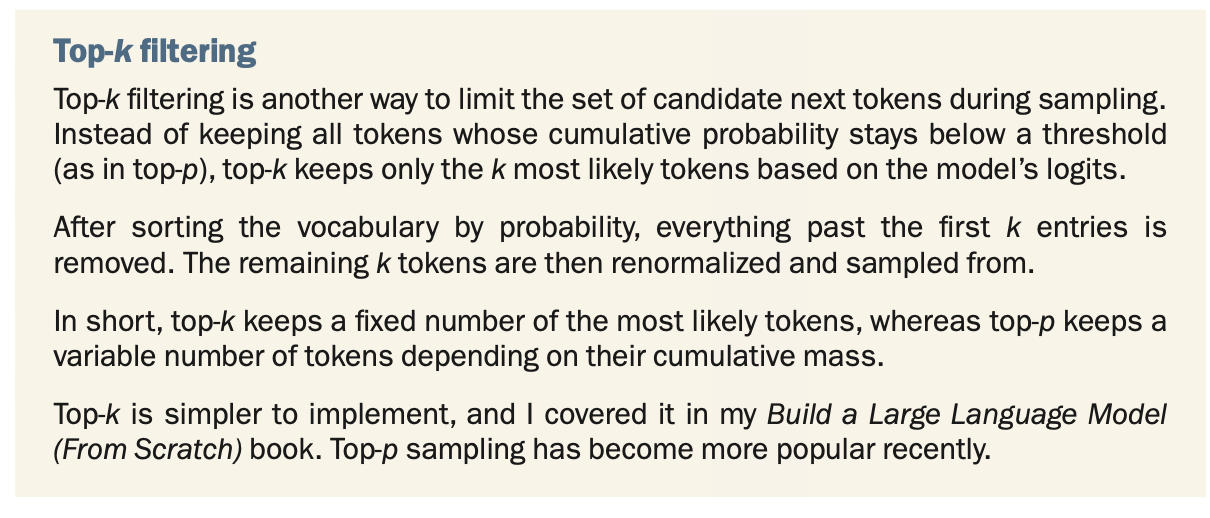


# 4.6 Improving response accuracy with self-consistency

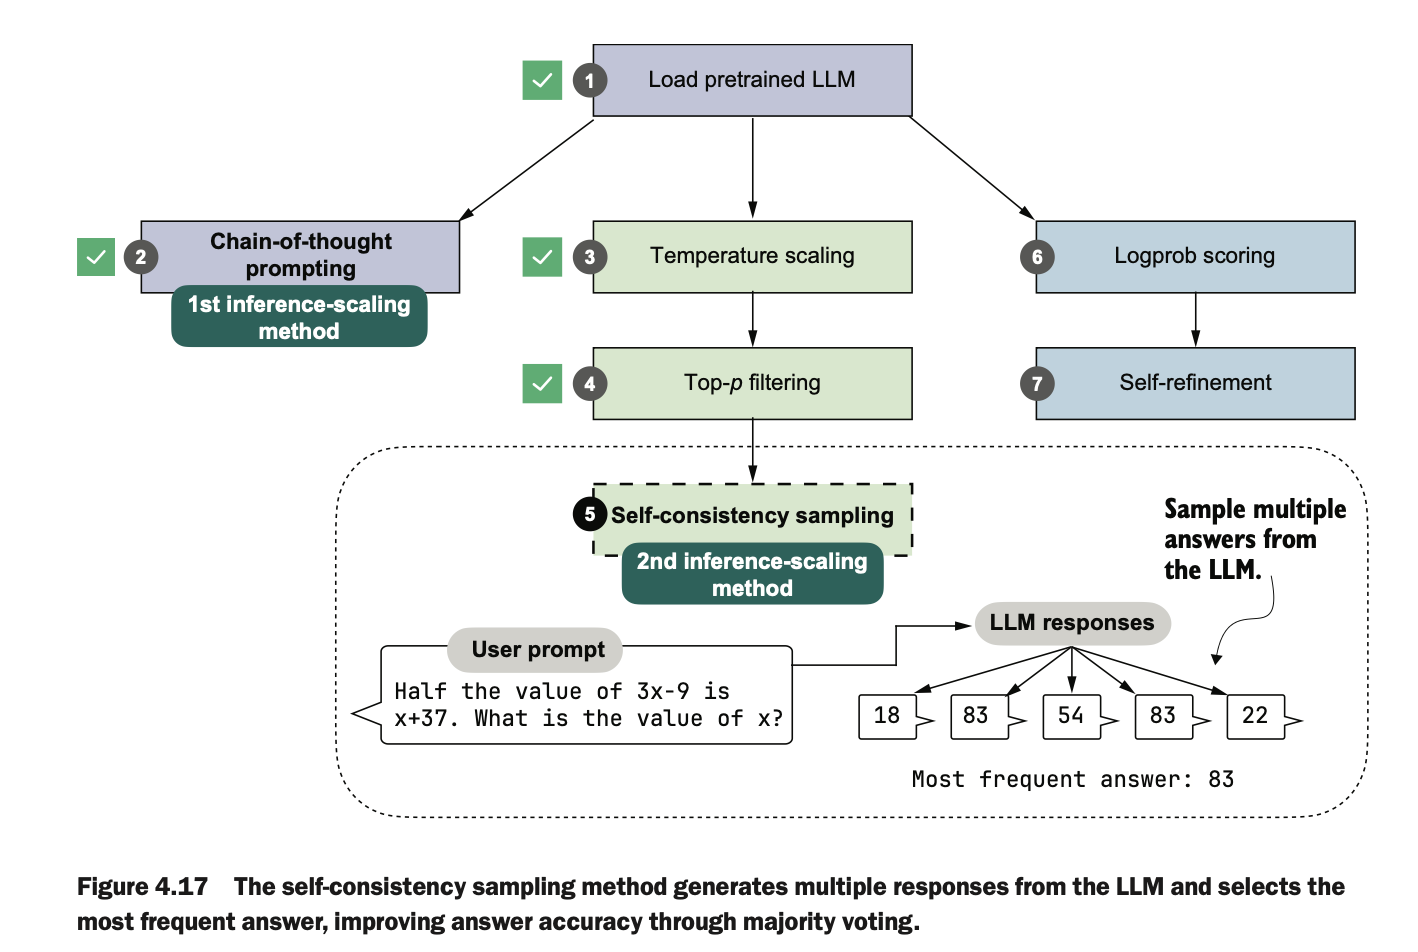


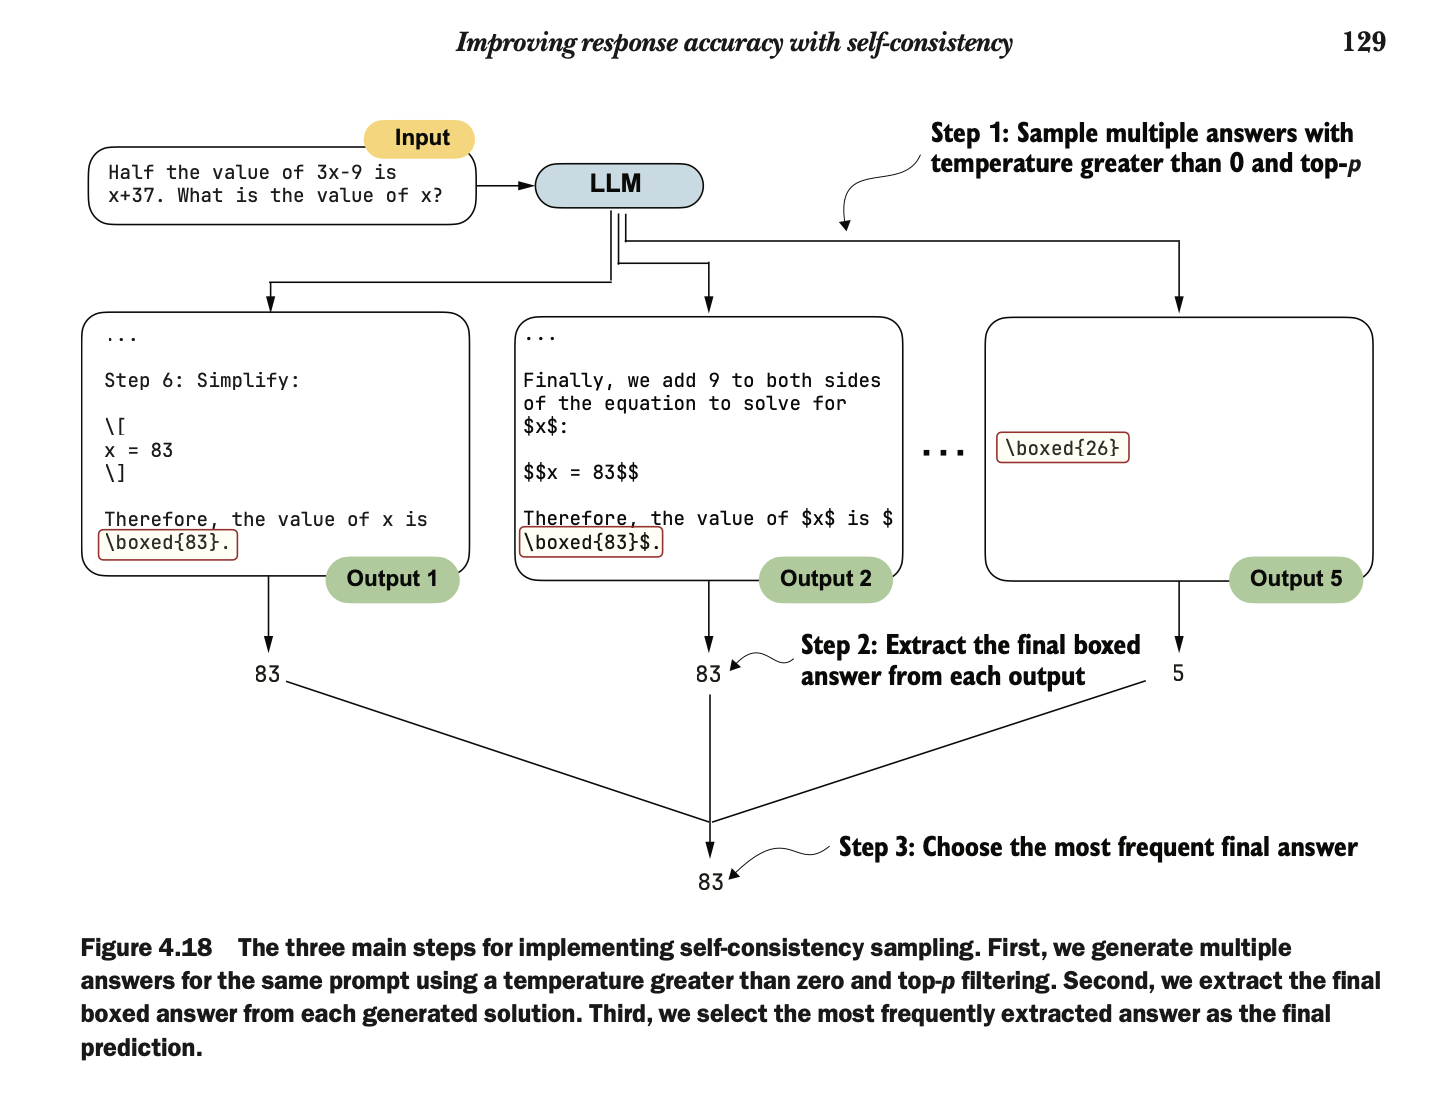


In [65]:
# Listing 4.17 Text generation with top-p filtering

from reasoning_from_scratch.ch03 import extract_final_candidate
from collections import Counter


def self_consistency_vote(
    model,
    tokenizer,
    prompt,
    device,
    num_samples=10,
    temperature=0.8,
    top_p=0.9,
    max_new_tokens=2048,
    show_progress=True,
    show_long_answer=False,
    seed=None,
):
    full_answers, short_answers = [], []

    # 1) Sample multiple answers
    for i in range(num_samples):
        if seed is not None:
            torch.manual_seed(seed + i + 1)

        answer = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            device=device,
            max_new_tokens=max_new_tokens,
            verbose=show_long_answer,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature,
            top_p=top_p,
        )

        # 2) Extract the final (short) answer from each answer
        short = extract_final_candidate(answer, fallback="number_then_full")
        full_answers.append(answer)
        short_answers.append(short)
        if show_progress:
            print(f"[Sample {i+1}/{num_samples}] → {short!r}")

    # 3) Choose the most frequent final answer (self-consistency vote)
    counts = Counter(short_answers)
    groups = {s: [] for s in counts}
    for idx, s in enumerate(short_answers):
        groups[s].append(idx)

    mc = counts.most_common()
    if not mc:
        majority_winners, final_answer = [], None
    else:
        top_freq = mc[0][1]
        majority_winners = [s for s, f in mc if f == top_freq]
        final_answer = mc[0][0] if len(majority_winners) == 1 else None

    return {
        "full_answers": full_answers,
        "short_answers": short_answers,
        "counts": dict(counts),
        "groups": groups,
        "majority_winners": majority_winners,
        "final_answer": final_answer,
    }

- In short, the self-consistency method in listing 4.17 does the following:
  1. Samples multiple answers with temperature greater than 0 and top-p
  2. Extracts the final boxed answer from each response

  3. Chooses the most frequent final answer

- Additional tips :
  - If all (long) answers look nearly identical, increase temperature gently to
    increase diversity

  - If (long) answers look off, decrease temperature

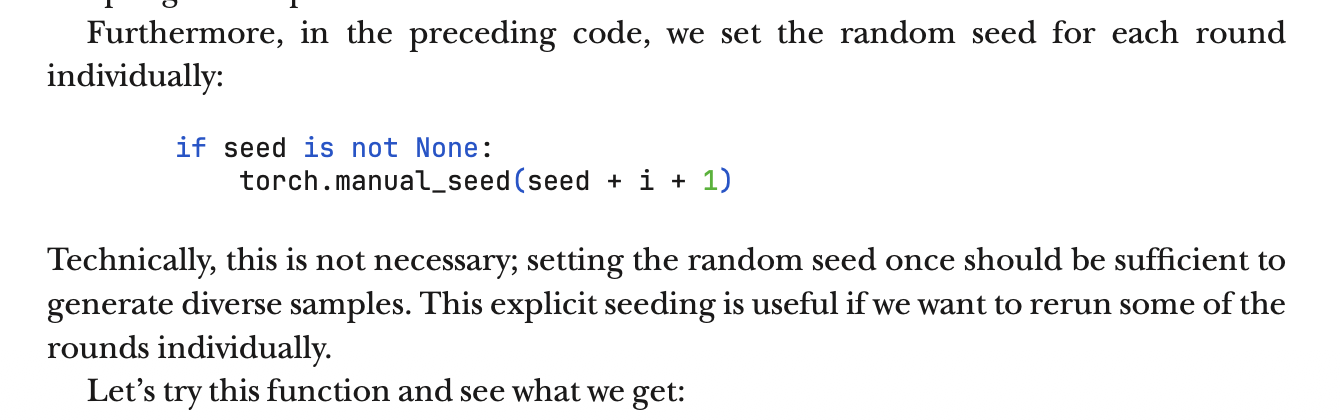


In [66]:
results = self_consistency_vote(
    model,
    tokenizer,
    prompt,
    device=device,
    num_samples=5,
    temperature=0.8,
    top_p=0.9,
    max_new_tokens=2048,
    seed=123,
    show_progress=True,
)

[Sample 1/5] → '83'
[Sample 2/5] → '22'
[Sample 3/5] → '54'
[Sample 4/5] → '83'
[Sample 5/5] → '61'


In [68]:
print(results["final_answer"])

83


In [69]:
print(results["full_answers"][0])

 To find the value of \( x \), let's solve the equation step by step.

1. **Given Equation:**
   \[
   \frac{1}{2} \times (3x - 9) = x + 37
   \]

2. **Multiply Both Sides by 2 to Eliminate the Fraction:**
   \[
   2 \times \frac{1}{2} \times (3x - 9) = 2 \times (x + 37)
   \]
   \[
   3x - 9 = 2x + 74
   \]

3. **Subtract \( 2x \) from Both Sides to Get:**
   \[
   3x - 2x - 9 = 74
   \]
   \[
   x - 9 = 74
   \]

4. **Add 9 to Both Sides to Solve for \( x \):**
   \[
   x = 74 + 9
   \]
   \[
   x = 83
   \]

**Final Answer:**
\[
\boxed{83}
\]


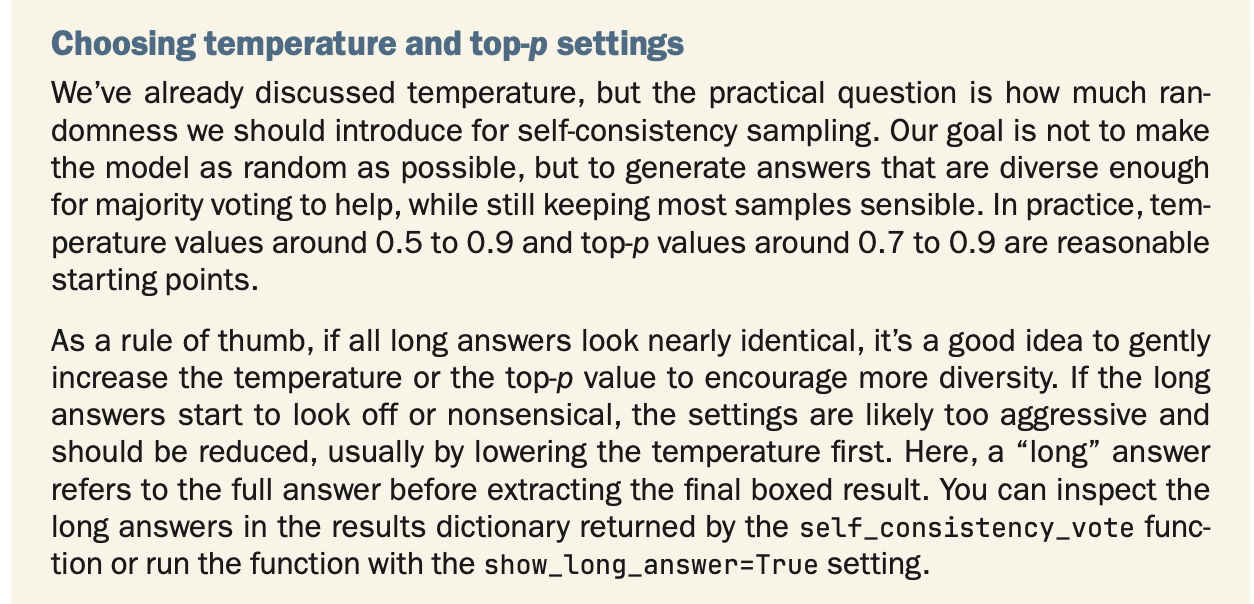


In [71]:
# Let’s combine chain-of-thought prompting with self-consistency sampling:
results = self_consistency_vote(
    model,
    tokenizer,
    prompt + "\n\nExplain step by step.",
    device=device,
    num_samples=5,
    temperature=0.8,
    top_p=0.9,
    max_new_tokens=2048,
    seed=123,
    show_progress=True,
)

[Sample 1/5] → 'x = 83'
[Sample 2/5] → '83'
[Sample 3/5] → '83'
[Sample 4/5] → '83'
[Sample 5/5] → '83'


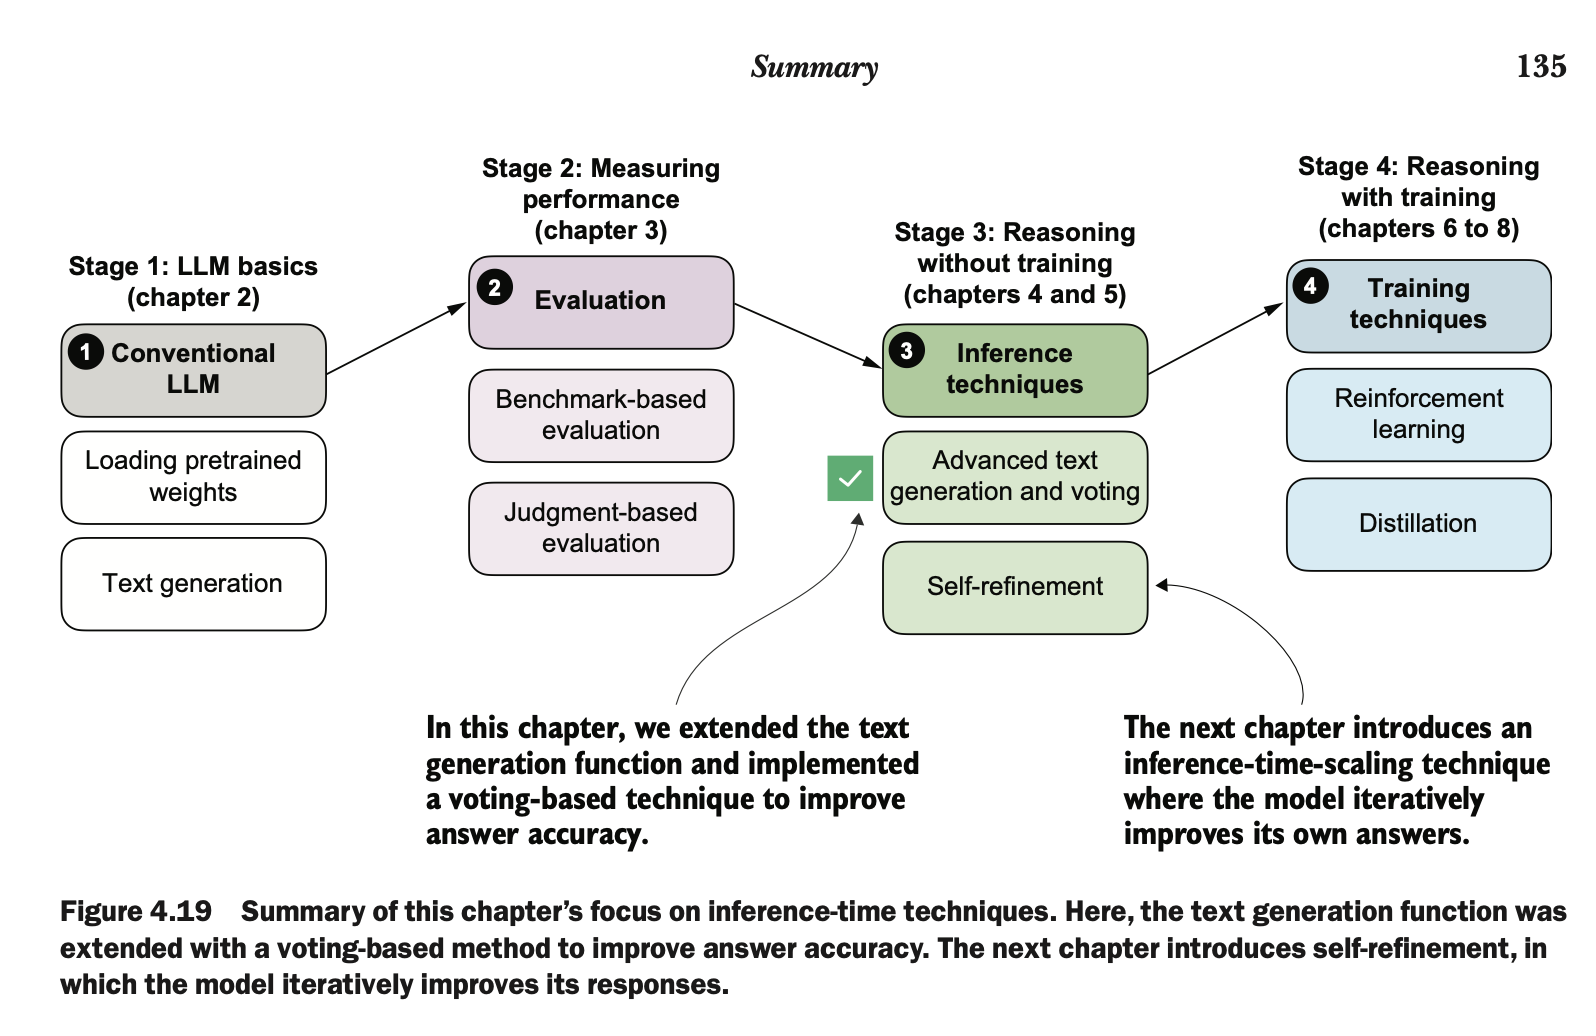